In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_rel, pearsonr, ttest_ind
from scipy.spatial.distance import euclidean, cosine,pdist, squareform
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

In [2]:
vision_pp = np.load('data/evals/perspective_taking/features/perspective/vision_tower_features.npy')
multimodal_pp = np.load('data/evals/perspective_taking/features/perspective/multimodal_projector_features.npy')
language_pp = np.load('data/evals/perspective_taking/features/perspective/language_model_features.npy')
vision_pp.shape, multimodal_pp.shape, language_pp.shape

((24, 577, 1024), (24, 576, 5120), (24, 645, 5120))

In [3]:
vision_base = np.load('data/evals/perspective_taking/features/base/vision_tower_features.npy')
multimodal_base = np.load('data/evals/perspective_taking/features/base/multimodal_projector_features.npy')
language_base = np.load('data/evals/perspective_taking/features/base/language_model_features.npy')
vision_base.shape, multimodal_base.shape, language_base.shape

((24, 577, 1024), (24, 576, 5120), (24, 645, 5120))

###

For preliminary analyses we'll start by averaging the middle (n_token) dimension to get one vector representing each image input

In [4]:
vision_pp_mean = np.mean(vision_pp, axis=1)
multimodal_pp_mean = np.mean(multimodal_pp, axis=1)
language_pp_mean = np.mean(language_pp, axis=1)
vision_base_mean = np.mean(vision_base, axis=1)
multimodal_base_mean = np.mean(multimodal_base, axis=1)
language_base_mean = np.mean(language_base, axis=1)
vision_pp_mean.shape, multimodal_pp_mean.shape, language_pp_mean.shape, vision_base_mean.shape, multimodal_base_mean.shape, language_base_mean.shape

((24, 1024), (24, 5120), (24, 5120), (24, 1024), (24, 5120), (24, 5120))

### Preliminary investigation

In [5]:
# find where pp does not equal base
np.where(vision_pp_mean != vision_base_mean)

(array([], dtype=int64), array([], dtype=int64))

In [6]:
np.where(multimodal_pp_mean != multimodal_base_mean)

(array([ 0,  0,  0, ..., 23, 23, 23], dtype=int64),
 array([   0,    1,    2, ..., 5117, 5118, 5119], dtype=int64))

In [7]:
np.where(language_pp_mean != language_base_mean)

(array([ 0,  0,  0, ..., 23, 23, 23], dtype=int64),
 array([   0,    1,    2, ..., 5117, 5118, 5119], dtype=int64))

In [8]:
angles = [0, 45, 60, 90, 120, 135, 180, 225, 240, 270, 300, 315] * 2
# egocentric cube directions (where in image space the cube is located)
left_ans_direction = [0] * 3 + [2] + [1] * 5 + [2] + [0] * 2  # 0 for left, 1 for right, 2 for perpendicular
right_ans_direction = [1] * 3 + [2] + [0] * 5 + [2] + [1] * 2  # 0 for left, 1 for right, 2 for perpendicular
cube_direction = left_ans_direction + right_ans_direction  # 0 for left, 1 for right

import pandas as pd
design_df = pd.DataFrame({
    'angle': angles,
    'cube_direction': cube_direction  # 0 for left, 1 for right
})

print("Design DataFrame Head:")
print(design_df.head())
print("\nDesign DataFrame Tail:")
print(design_df.tail())

Design DataFrame Head:
   angle  cube_direction
0      0               0
1     45               0
2     60               0
3     90               2
4    120               1

Design DataFrame Tail:
    angle  cube_direction
19    225               0
20    240               0
21    270               2
22    300               1
23    315               1


--- Per-Image Activation Vector Differences (PP vs. Base) ---

Analyzing Layer: multimodal_projector
  Euclidean Distance (Min: 33.5625, Max: 67.9375, Mean: 46.7500)
  Cosine Distance (Min: 0.1250, Max: 0.2983, Mean: 0.2169)
  Mean Absolute Difference (Min: 0.3601, Max: 0.7441, Mean: 0.5068)


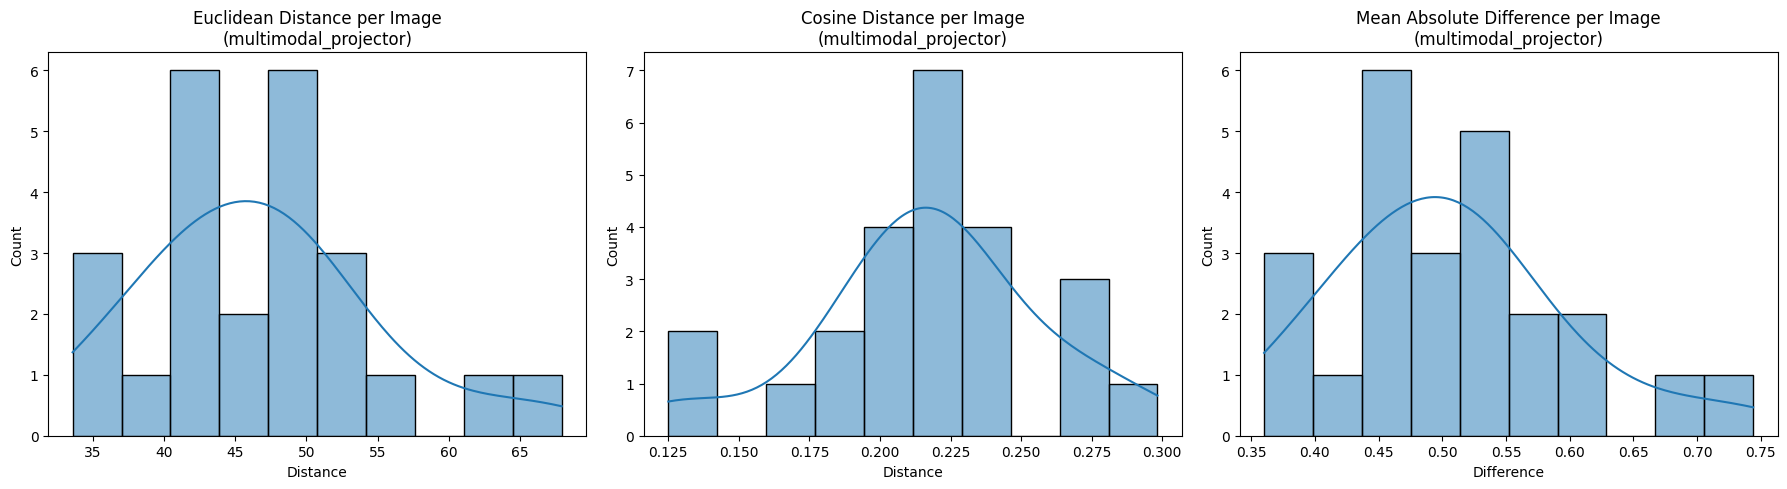


Analyzing Layer: language_model
  Euclidean Distance (Min: 68.6875, Max: 96.1250, Mean: 79.1250)
  Cosine Distance (Min: 0.4858, Max: 0.7965, Mean: 0.6230)
  Mean Absolute Difference (Min: 0.7578, Max: 1.0674, Mean: 0.8779)


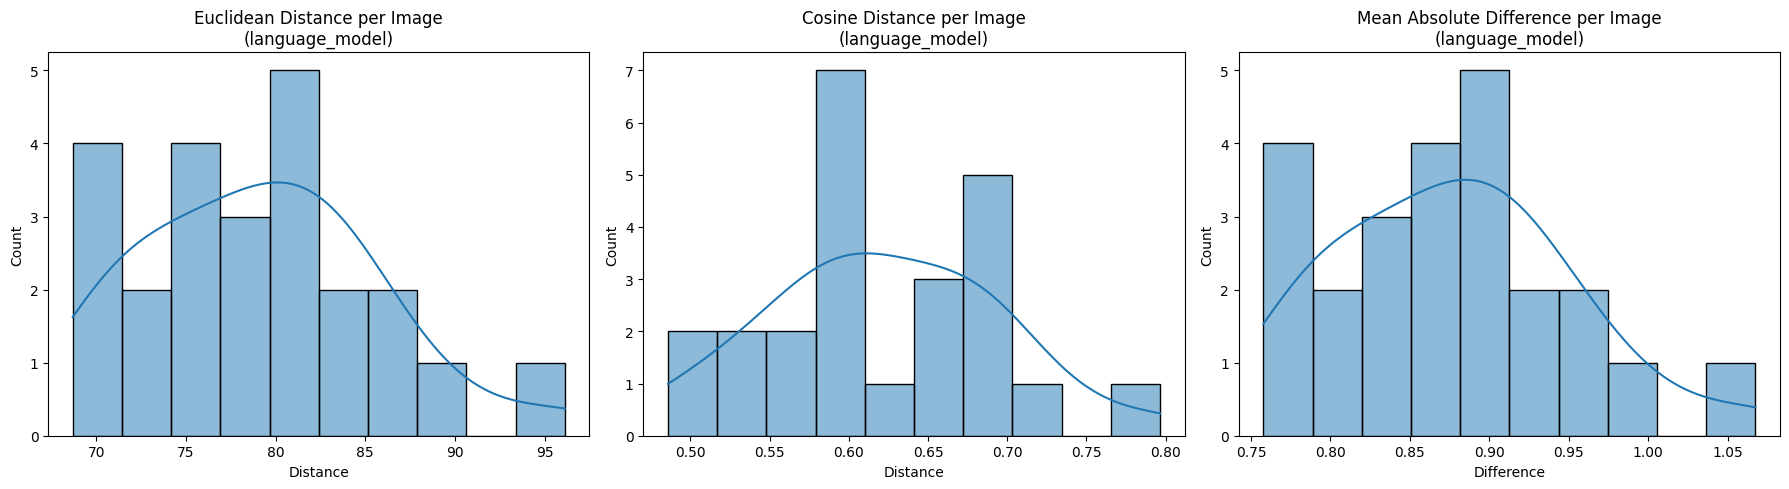

In [9]:
scaler = StandardScaler()

multimodal_pp_scaled = scaler.fit_transform(multimodal_pp_mean)
multimodal_base_scaled = scaler.fit_transform(multimodal_base_mean)
language_pp_scaled = scaler.fit_transform(language_pp_mean)
language_base_scaled = scaler.fit_transform(language_base_mean)

# Define the layers and their corresponding scaled matrices
layers_to_analyze = {
    'multimodal_projector': {'pp': multimodal_pp_scaled, 'base': multimodal_base_scaled},
    'language_model': {'pp': language_pp_scaled, 'base': language_base_scaled}
}

print("--- Per-Image Activation Vector Differences (PP vs. Base) ---")

for layer_name, data in layers_to_analyze.items():
    pp_mat = data['pp']
    base_mat = data['base']
    num_images = pp_mat.shape[0]

    euclidean_distances = []
    cosine_distances = []
    mean_abs_diffs = []

    for i in range(num_images):
        pp_vec = pp_mat[i]
        base_vec = base_mat[i]

        # Euclidean Distance
        euclidean_distances.append(euclidean(pp_vec, base_vec))

        # Cosine Distance (1 - Cosine Similarity)
        # Handle potential zero norm for cosine similarity
        norm_pp = np.linalg.norm(pp_vec)
        norm_base = np.linalg.norm(base_vec)
        if norm_pp > 0 and norm_base > 0:
            cosine_distances.append(cosine(pp_vec, base_vec))
        else:
            cosine_distances.append(np.nan) # Or 1.0 if vectors are identical zero vectors

        # Mean Absolute Difference
        mean_abs_diffs.append(np.mean(np.abs(pp_vec - base_vec)))

    print(f"\nAnalyzing Layer: {layer_name}")
    print(f"  Euclidean Distance (Min: {np.min(euclidean_distances):.4f}, Max: {np.max(euclidean_distances):.4f}, Mean: {np.mean(euclidean_distances):.4f})")
    print(f"  Cosine Distance (Min: {np.nanmin(cosine_distances):.4f}, Max: {np.nanmax(cosine_distances):.4f}, Mean: {np.nanmean(cosine_distances):.4f})")
    print(f"  Mean Absolute Difference (Min: {np.min(mean_abs_diffs):.4f}, Max: {np.max(mean_abs_diffs):.4f}, Mean: {np.mean(mean_abs_diffs):.4f})")

    # Plot distributions
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(euclidean_distances, kde=True, bins=min(num_images, 10))
    plt.title(f'Euclidean Distance per Image\n({layer_name})')
    plt.xlabel('Distance')
    plt.ylabel('Count')

    plt.subplot(1, 3, 2)
    sns.histplot(cosine_distances, kde=True, bins=min(num_images, 10))
    plt.title(f'Cosine Distance per Image\n({layer_name})')
    plt.xlabel('Distance')
    plt.ylabel('Count')

    plt.subplot(1, 3, 3)
    sns.histplot(mean_abs_diffs, kde=True, bins=min(num_images, 10))
    plt.title(f'Mean Absolute Difference per Image\n({layer_name})')
    plt.xlabel('Difference')
    plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

In [10]:
# To get image-specific details, you can store these in a DataFrame:
results_df_list = []
for layer_name, data in layers_to_analyze.items():
    pp_mat = data['pp']
    base_mat = data['base']
    num_images = pp_mat.shape[0]

    for i in range(num_images):
        pp_vec = pp_mat[i]
        base_vec = base_mat[i]

        euc_dist = euclidean(pp_vec, base_vec)
        
        norm_pp = np.linalg.norm(pp_vec)
        norm_base = np.linalg.norm(base_vec)
        cos_dist = cosine(pp_vec, base_vec) if norm_pp > 0 and norm_base > 0 else 1.0 # Treat zero norm as max dissimilarity
        
        mean_abs = np.mean(np.abs(pp_vec - base_vec))

        results_df_list.append({
            'layer': layer_name,
            'image_idx': i,
            'euclidean_distance': euc_dist,
            'cosine_distance': cos_dist,
            'mean_abs_difference': mean_abs
        })

per_image_diff_df = pd.DataFrame(results_df_list)
print("\nPer-Image Differences DataFrame Head:")
print(per_image_diff_df.head())


Per-Image Differences DataFrame Head:
                  layer  image_idx  euclidean_distance  cosine_distance  \
0  multimodal_projector          0            51.68750         0.175781   
1  multimodal_projector          1            54.15625         0.240723   
2  multimodal_projector          2            45.65625         0.268066   
3  multimodal_projector          3            67.93750         0.298340   
4  multimodal_projector          4            39.34375         0.234863   

   mean_abs_difference  
0             0.555664  
1             0.597656  
2             0.497559  
3             0.744141  
4             0.419434  


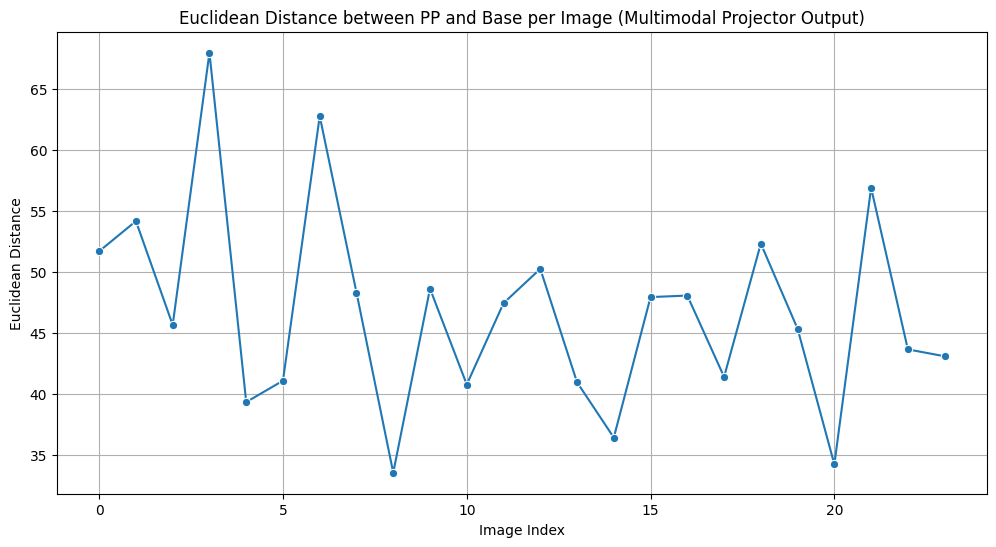

In [11]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=per_image_diff_df[per_image_diff_df['layer'] == 'multimodal_projector'],
             x='image_idx', y='euclidean_distance', marker='o')
plt.title('Euclidean Distance between PP and Base per Image (Multimodal Projector Output)')
plt.xlabel('Image Index')
plt.ylabel('Euclidean Distance')
plt.grid(True)
plt.show()

In [12]:
design_df_with_idx = design_df.copy()
design_df_with_idx['image_idx'] = design_df_with_idx.index

merged_diff_df = pd.merge(per_image_diff_df, design_df_with_idx, on='image_idx')
print("\nMerged Differences DataFrame Head (with experimental factors):")
print(merged_diff_df.head())


Merged Differences DataFrame Head (with experimental factors):
                  layer  image_idx  euclidean_distance  cosine_distance  \
0  multimodal_projector          0            51.68750         0.175781   
1        language_model          0            86.00000         0.556396   
2  multimodal_projector          1            54.15625         0.240723   
3        language_model          1            81.62500         0.632080   
4  multimodal_projector          2            45.65625         0.268066   

   mean_abs_difference  angle  cube_direction  
0             0.555664      0               0  
1             0.960449      0               0  
2             0.597656     45               0  
3             0.904785     45               0  
4             0.497559     60               0  


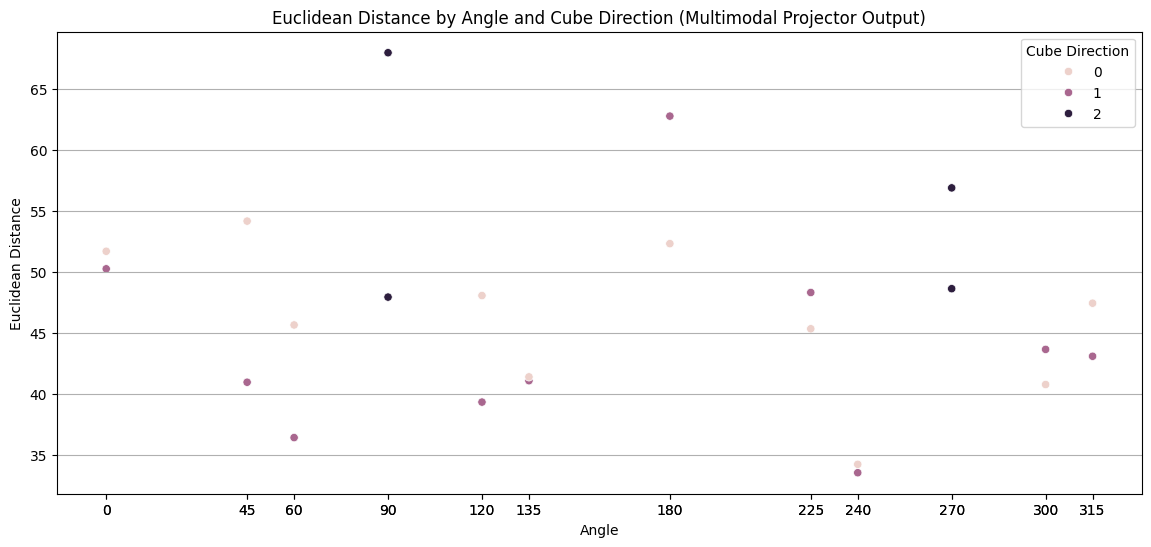

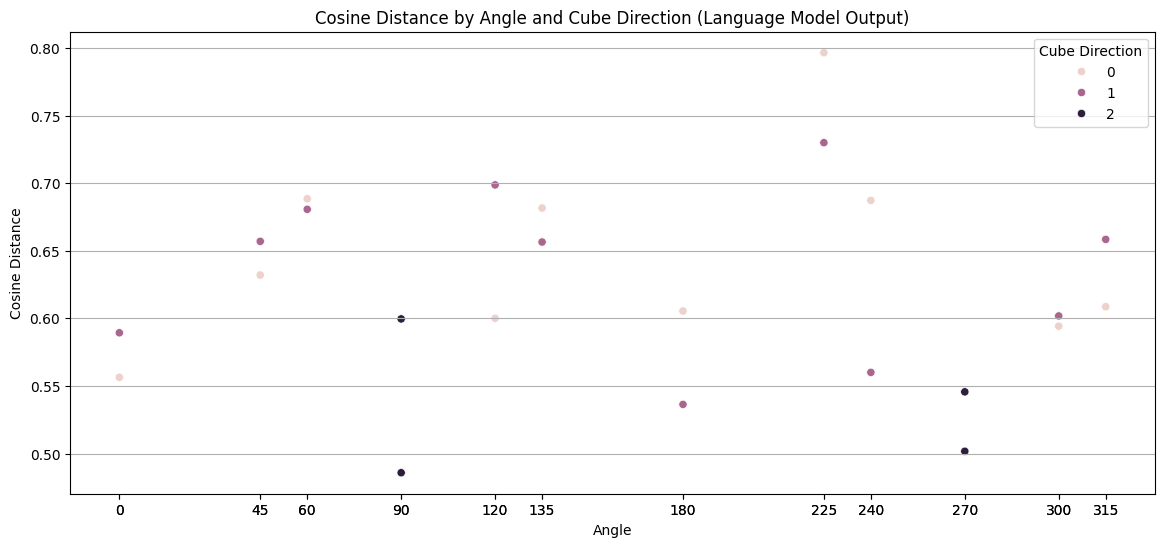

In [13]:
# Now you can visualize differences as a function of your experimental factors:
plt.figure(figsize=(14, 6))
sns.scatterplot(data=merged_diff_df[merged_diff_df['layer'] == 'multimodal_projector'],
            x='angle', y='euclidean_distance', hue='cube_direction')
plt.title('Euclidean Distance by Angle and Cube Direction (Multimodal Projector Output)')
plt.xlabel('Angle')
plt.xticks(angles)
plt.ylabel('Euclidean Distance')
plt.legend(title='Cube Direction')
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(14, 6))
sns.scatterplot(data=merged_diff_df[merged_diff_df['layer'] == 'language_model'],
            x='angle', y='cosine_distance', hue='cube_direction')
plt.title('Cosine Distance by Angle and Cube Direction (Language Model Output)')
plt.xlabel('Angle')
plt.xticks(angles)
plt.ylabel('Cosine Distance')
plt.legend(title='Cube Direction')
plt.grid(axis='y')
plt.show()

### 1.1 Multivariate analyses

RSA

In [14]:
angles

[0,
 45,
 60,
 90,
 120,
 135,
 180,
 225,
 240,
 270,
 300,
 315,
 0,
 45,
 60,
 90,
 120,
 135,
 180,
 225,
 240,
 270,
 300,
 315]

In [63]:
print(design_df.head())

# let's make a new column called angular_difference where 45 degrees is the same as 315 degrees
angular_difference = [0, 45, 60, 90, 120, 135, 180, 135, 120, 90, 60, 45] * 2
design_df['angular_difference'] = angular_difference
allo_cube_direction = [0] * 12 + [1] * 12  # 0 for left, 1 for right
design_df['allo_cube_direction'] = allo_cube_direction
print("\nDesign DataFrame with Angular Difference and Allocentric Cube Direction:")
print(design_df.head())

   angle  cube_direction  angular_difference  alignment
0      0               0                   0          0
1     45               0                  45          0
2     60               0                  60          0
3     90               2                  90          2
4    120               1                 120          1

Design DataFrame with Angular Difference and Allocentric Cube Direction:
   angle  cube_direction  angular_difference  alignment  allo_cube_direction
0      0               0                   0          0                    0
1     45               0                  45          0                    0
2     60               0                  60          0                    0
3     90               2                  90          2                    0
4    120               1                 120          1                    0


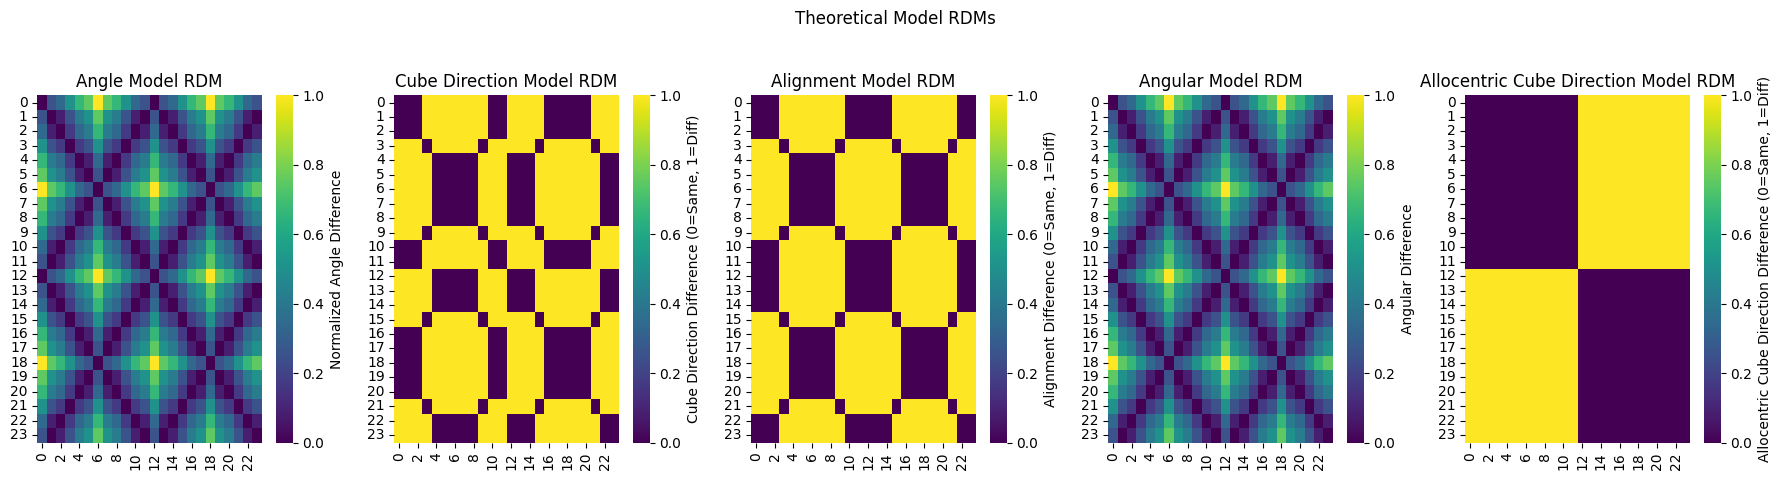

In [69]:
rsa_results = []

# --- Create Model RDMs (once, as they are based on stimuli, not model activations) ---

# Angle Model RDM: Dissimilarity is proportional to absolute angular difference
# Normalize to 0-1 range based on max possible difference (330 - 0 = 330)
max_angle_diff = design_df['angular_difference'].max() - design_df['angular_difference'].min()
angle_diffs = np.abs(design_df['angular_difference'].values[:, None] - design_df['angular_difference'].values[None, :])
angle_model_rdm = angle_diffs / max_angle_diff if max_angle_diff > 0 else np.zeros_like(angle_diffs)
angle_model_rdm_flat = angle_model_rdm[np.triu_indices(24, k=1)]

# Cube Direction Model RDM: 0 if same direction, 1 if different direction
cube_direction_diffs = (design_df['cube_direction'].values[:, None] != design_df['cube_direction'].values[None, :]).astype(int)
cube_direction_model_rdm = cube_direction_diffs
cube_direction_model_rdm_flat = cube_direction_model_rdm[np.triu_indices(24, k=1)]

# alignment
alignment_diffs = (design_df['alignment'].values[:, None] != design_df['alignment'].values[None, :]).astype(int)
alignment_model_rdm = alignment_diffs
alignment_model_rdm_flat = alignment_model_rdm[np.triu_indices(24, k=1)]

# angular difference
angular_diffs = np.abs(design_df['angular_difference'].values[:, None] - design_df['angular_difference'].values[None, :])
angular_model_rdm = angular_diffs / max_angle_diff if max_angle_diff > 0 else np.zeros_like(angular_diffs)
angular_model_rdm_flat = angular_model_rdm[np.triu_indices(24, k=1)]

# allocentric cube direction
allo_cube_direction_diffs = (design_df['allo_cube_direction'].values[:, None] != design_df['allo_cube_direction'].values[None, :]).astype(int)
allo_cube_direction_model_rdm = allo_cube_direction_diffs
allo_cube_direction_model_rdm_flat = allo_cube_direction_model_rdm[np.triu_indices(24, k=1)]

# Visualize Model RDMs (optional, but good for sanity check)
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
sns.heatmap(angle_model_rdm, ax=axes[0], cmap='viridis', cbar_kws={'label': 'Normalized Angle Difference'})
axes[0].set_title('Angle Model RDM')
sns.heatmap(cube_direction_model_rdm, ax=axes[1], cmap='viridis', cbar_kws={'label': 'Cube Direction Difference (0=Same, 1=Diff)'})
axes[1].set_title('Cube Direction Model RDM')
sns.heatmap(alignment_model_rdm, ax=axes[2], cmap='viridis', cbar_kws={'label': 'Alignment Difference (0=Same, 1=Diff)'})
axes[2].set_title('Alignment Model RDM')
sns.heatmap(angular_model_rdm, ax=axes[3], cmap='viridis', cbar_kws={'label': 'Angular Difference'})
axes[3].set_title('Angular Model RDM')
sns.heatmap(allo_cube_direction_model_rdm, ax=axes[4], cmap='viridis', cbar_kws={'label': 'Allocentric Cube Direction Difference (0=Same, 1=Diff)'})
axes[4].set_title('Allocentric Cube Direction Model RDM')
plt.suptitle('Theoretical Model RDMs')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [55]:
# Define significance stars
def p_to_stars(p):
    if p < 0.0001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''
    
def plot_rsa_with_stars(rsa_df, factor_name, title):
    subset = rsa_df[rsa_df['factor'] == factor_name]

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=subset,
        x='layer', y='correlation', hue='model_type',
        palette={'base': 'skyblue', 'pp': 'salmon'},
        edgecolor='black'
    )

    # Add significance stars above bars
    for i, bar in enumerate(ax.patches):
        height = bar.get_height()
        if height <= 0:  # skip dummy or zero-height patches
            continue

        # Get matching p-value & star
        star = subset.iloc[i]['sig_stars'] if i < len(subset) else ''
        if star:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.02,  # adjust offset as needed
                star,
                ha='center', va='bottom', fontsize=12, color='black', weight='bold'
            )

    # Format plot
    plt.title(title)
    plt.xlabel('Layer')
    plt.ylabel('Spearman Correlation (rho)')
    plt.ylim(0, 1)
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Model Type')
    plt.tight_layout()
    plt.show()


--- Performing RSA ---
Layer: multimodal_projector, Model: base
  Correlation with Angle Model: 0.4238 (p=0.0000)
  Correlation with Cube Direction Model: 0.0468 (p=0.4388)
  Correlation with Alignment Model: 0.4062 (p=0.0000)
  Correlation with Angular Difference Model: 0.4238 (p=0.0000)
  Correlation with Allocentric Cube Direction Model: -0.0470 (p=0.4370)
Layer: multimodal_projector, Model: pp
  Correlation with Angle Model: 0.5129 (p=0.0000)
  Correlation with Cube Direction Model: 0.0605 (p=0.3163)
  Correlation with Alignment Model: 0.5214 (p=0.0000)
  Correlation with Angular Difference Model: 0.5129 (p=0.0000)
  Correlation with Allocentric Cube Direction Model: -0.0538 (p=0.3732)
Layer: language_model, Model: base
  Correlation with Angle Model: 0.2801 (p=0.0000)
  Correlation with Cube Direction Model: 0.0768 (p=0.2036)
  Correlation with Alignment Model: 0.3521 (p=0.0000)
  Correlation with Angular Difference Model: 0.2801 (p=0.0000)
  Correlation with Allocentric Cube Dir

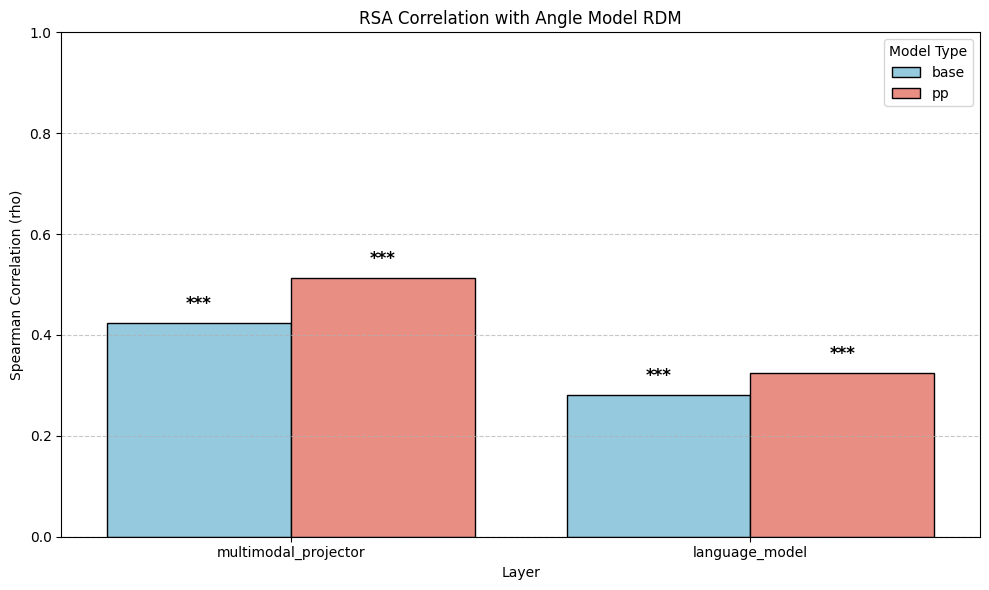

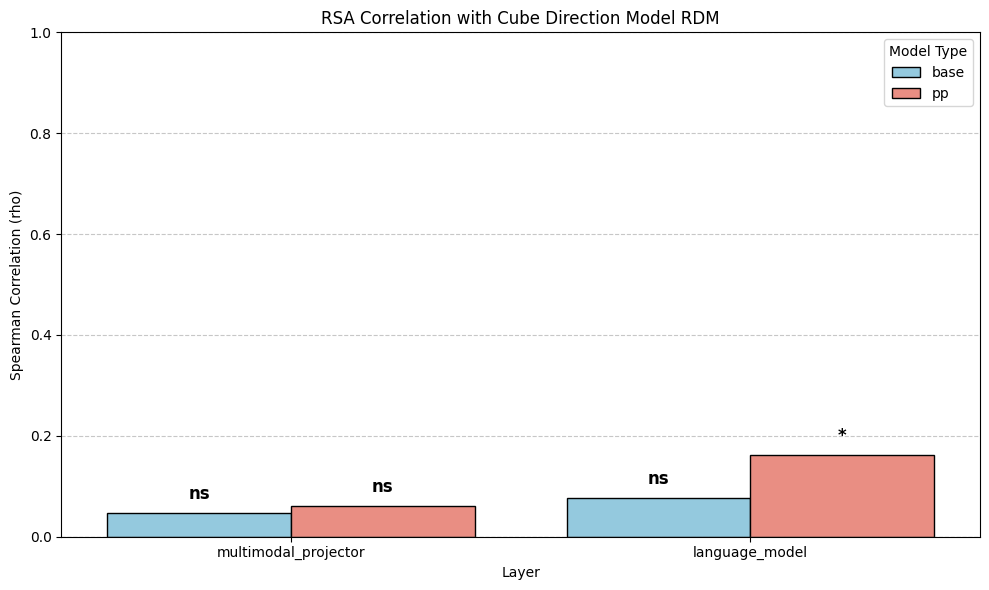

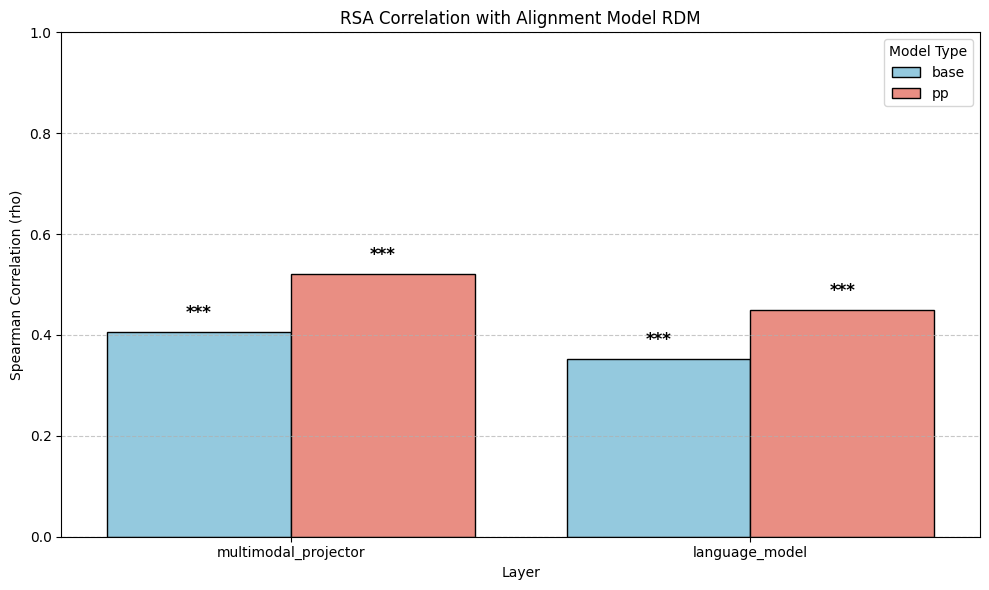

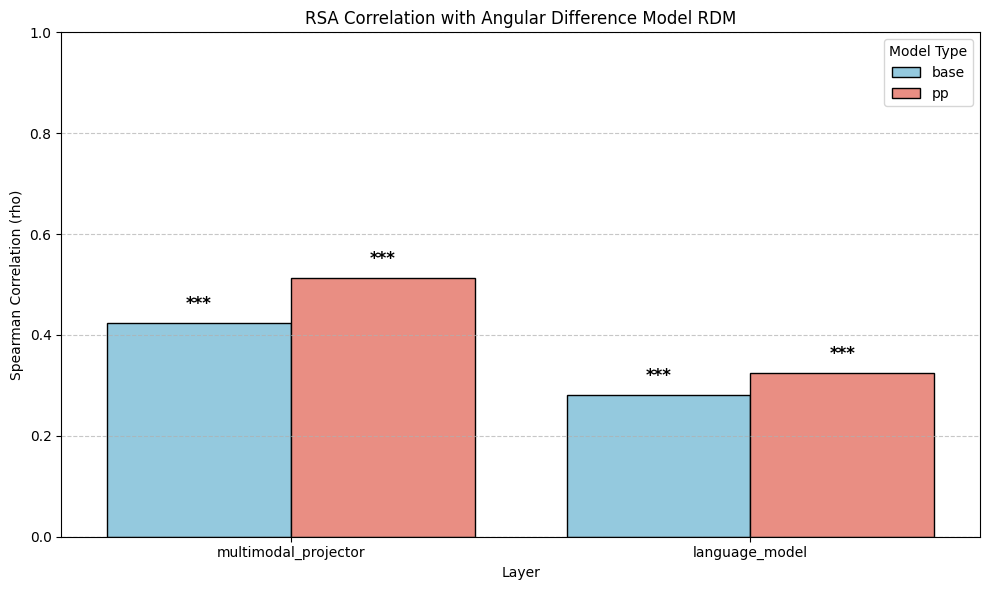

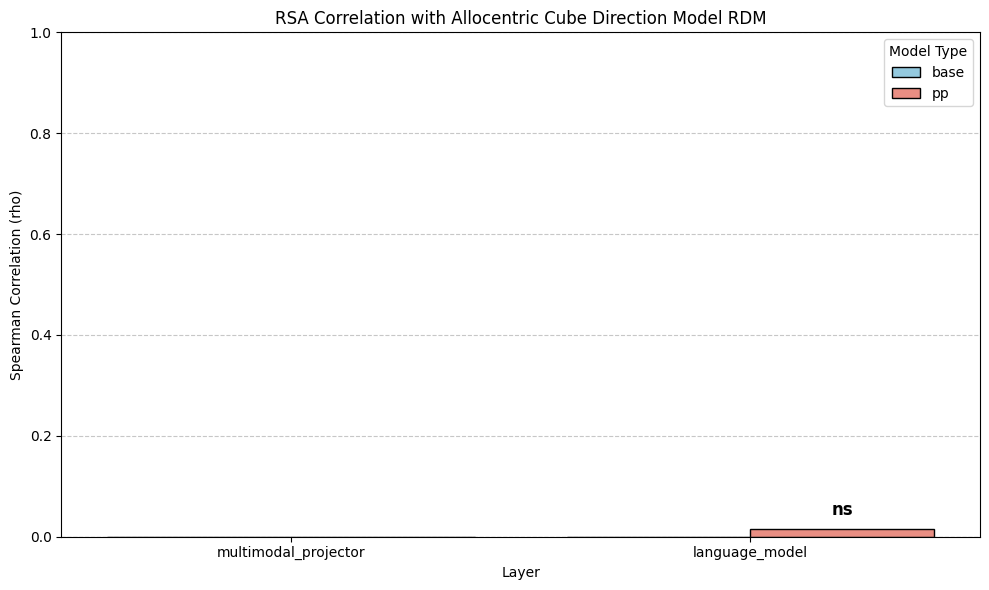

In [70]:
# --- Perform RSA for each LLaVA layer and model type ---
print("\n--- Performing RSA ---")

for layer_name, data in layers_to_analyze.items():
    for model_type in ['base', 'pp']:
        current_activations = data[model_type]

        # Compute LLaVA RDM using 1 - Pearson correlation as dissimilarity
        # Ensure activations are float to prevent type errors with corrcoef
        llava_rdm = squareform(pdist(current_activations.astype(float), metric='correlation'))
        llava_rdm_flat = llava_rdm[np.triu_indices(24, k=1)]

        # Compare with Angle Model RDM
        angle_corr, angle_p = spearmanr(llava_rdm_flat, angle_model_rdm_flat)
        
        # Compare with Cube Direction Model RDM
        cube_direction_corr, cube_direction_p = spearmanr(llava_rdm_flat, cube_direction_model_rdm_flat)

        # compare Alignment Model RDM
        alignment_corr, alignment_p = spearmanr(llava_rdm_flat, alignment_model_rdm_flat)

        # compare Angular Difference Model RDM
        angular_corr, angular_p = spearmanr(llava_rdm_flat, angular_model_rdm_flat)

        # compare cube direction allocentric Model RDM
        allo_cube_direction_corr, allo_cube_direction_p = spearmanr(llava_rdm_flat, allo_cube_direction_model_rdm_flat)

        rsa_results.append({
            'layer': layer_name,
            'model_type': model_type,
            'factor': 'angle',
            'correlation': angle_corr,
            'p_value': angle_p
        })
        rsa_results.append({
            'layer': layer_name,
            'model_type': model_type,
            'factor': 'cube_direction',
            'correlation': cube_direction_corr,
            'p_value': cube_direction_p
        })
        rsa_results.append({
            'layer': layer_name,
            'model_type': model_type,
            'factor': 'alignment',
            'correlation': alignment_corr,
            'p_value': alignment_p
        })
        rsa_results.append({
            'layer': layer_name,
            'model_type': model_type,
            'factor': 'angular_difference',
            'correlation': angular_corr,
            'p_value': angular_p
        })
        rsa_results.append({
            'layer': layer_name,
            'model_type': model_type,
            'factor': 'allo_cube_direction',
            'correlation': allo_cube_direction_corr,
            'p_value': allo_cube_direction_p
        })

        print(f"Layer: {layer_name}, Model: {model_type}")
        print(f"  Correlation with Angle Model: {angle_corr:.4f} (p={angle_p:.4f})")
        print(f"  Correlation with Cube Direction Model: {cube_direction_corr:.4f} (p={cube_direction_p:.4f})")
        print(f"  Correlation with Alignment Model: {alignment_corr:.4f} (p={alignment_p:.4f})")
        print(f"  Correlation with Angular Difference Model: {angular_corr:.4f} (p={angular_p:.4f})")
        print(f"  Correlation with Allocentric Cube Direction Model: {allo_cube_direction_corr:.4f} (p={allo_cube_direction_p:.4f})")

# Convert results to DataFrame for easier plotting
rsa_df = pd.DataFrame(rsa_results)
# correct p-values for multiple comparisons
from statsmodels.stats.multitest import multipletests

# Apply FDR correction
rsa_df['p_corrected'] = multipletests(rsa_df['p_value'], method='fdr_bh')[1]
rsa_df['significant'] = rsa_df['p_corrected'] < 0.05
print("\nRSA Results with Corrected P-values:")
print(rsa_df.head())

rsa_df['sig_stars'] = rsa_df['p_corrected'].apply(p_to_stars)

# --- Visualization of RSA Results ---
plot_rsa_with_stars(rsa_df, 'angle', 'RSA Correlation with Angle Model RDM')
plot_rsa_with_stars(rsa_df, 'cube_direction', 'RSA Correlation with Cube Direction Model RDM')
plot_rsa_with_stars(rsa_df, 'alignment', 'RSA Correlation with Alignment Model RDM')
plot_rsa_with_stars(rsa_df, 'angular_difference', 'RSA Correlation with Angular Difference Model RDM')
plot_rsa_with_stars(rsa_df, 'allo_cube_direction', 'RSA Correlation with Allocentric Cube Direction Model RDM')


#### Bootstrap to test differences

In [71]:
n_boot = 1000
rng = np.random.default_rng(42)

bootstrap_results = []

# Loop over layers and model RDMs
for layer_name, data in layers_to_analyze.items():
    for factor_name, model_rdm_flat in {
        'angle': angle_model_rdm_flat,
        'cube_direction': cube_direction_model_rdm_flat,
        'alignment': alignment_model_rdm_flat,
        'angular_difference': angular_model_rdm_flat,
        'allo_cube_direction': allo_cube_direction_model_rdm_flat
    }.items():
        
        # Base and PP activations
        base_acts = data['base'].astype(float)
        pp_acts = data['pp'].astype(float)
        
        # Compute their RDMs once
        base_rdm = squareform(pdist(base_acts, metric='correlation'))
        pp_rdm = squareform(pdist(pp_acts, metric='correlation'))

        base_flat = base_rdm[np.triu_indices(len(base_rdm), k=1)]
        pp_flat = pp_rdm[np.triu_indices(len(pp_rdm), k=1)]

        # Bootstrap differences
        base_boot, pp_boot = [], []
        for _ in range(n_boot):
            idx = rng.choice(len(base_flat), len(base_flat), replace=True)
            base_corr, _ = spearmanr(base_flat[idx], model_rdm_flat[idx])
            pp_corr, _ = spearmanr(pp_flat[idx], model_rdm_flat[idx])
            base_boot.append(base_corr)
            pp_boot.append(pp_corr)

        base_boot = np.array(base_boot)
        pp_boot = np.array(pp_boot)
        diff_boot = pp_boot - base_boot

        for val in diff_boot:
            bootstrap_results.append({
                'layer': layer_name,
                'factor': factor_name,
                'diff_pp_base': val
            })

bootstrap_df = pd.DataFrame(bootstrap_results)
print("\nBootstrapped RSA differences (first few rows):")
print(bootstrap_df.head())


Bootstrapped RSA differences (first few rows):
                  layer factor  diff_pp_base
0  multimodal_projector  angle      0.087638
1  multimodal_projector  angle      0.113021
2  multimodal_projector  angle      0.077760
3  multimodal_projector  angle      0.099526
4  multimodal_projector  angle      0.106068


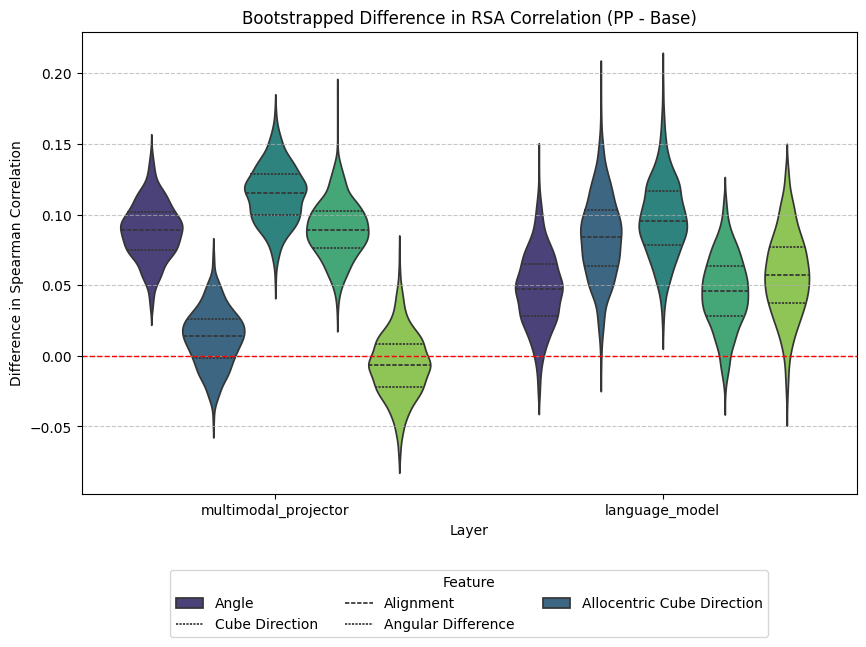

In [77]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=bootstrap_df,
    x='layer', y='diff_pp_base', hue='factor',
    inner='quartile', palette='viridis'
)
plt.title('Bootstrapped Difference in RSA Correlation (PP - Base)')
plt.xlabel('Layer')
plt.ylabel('Difference in Spearman Correlation')
plt.axhline(0, color='r', linestyle='--', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
feature_labels = ['Angle', 'Cube Direction', 'Alignment', 'Angular Difference', 'Allocentric Cube Direction']
plt.legend(title='Feature', labels=feature_labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.savefig('data/evals/visuals/bootstrap_rsa_results.png')

plt.show()


In [78]:
summary = (
    bootstrap_df
    .groupby(['layer', 'factor'])['diff_pp_base']
    .agg([
        ('mean_diff', 'mean'),
        ('ci_low', lambda x: np.percentile(x, 2.5)),
        ('ci_high', lambda x: np.percentile(x, 97.5)),
        ('p_value', lambda x: np.mean(x <= 0) * 2)  # two-tailed
    ])
    .reset_index()
)

# add stars for significance
def p_to_stars(p):
    if p < 0.0001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

summary['sig'] = summary['p_value'].apply(p_to_stars)
summary


,layer,factor,mean_diff,ci_low,ci_high,p_value,sig
0,language_model,alignment,0.097238,0.044524,0.154193,0.000,***
1,language_model,allo_cube_direction,0.057309,-0.000036,0.115550,0.052,ns
2,language_model,angle,0.046649,-0.004915,0.100399,0.078,ns
3,language_model,angular_difference,0.045282,-0.007703,0.093131,0.096,ns
4,language_model,cube_direction,0.083617,0.023212,0.144503,0.006,**
5,multimodal_projector,alignment,0.114349,0.074367,0.154637,0.000,***
6,multimodal_projector,allo_cube_direction,-0.006645,-0.051528,0.039969,1.256,ns
7,multimodal_projector,angle,0.088485,0.049720,0.127708,0.000,***
8,multimodal_projector,angular_difference,0.089463,0.050419,0.129866,0.000,***
9,multimodal_projector,cube_direction,0.012872,-0.027075,0.051442,0.542,ns


## ROI
Find neurons that are correlated with aligned/unaligned (on/off)

In [20]:
alignment = [0, 0, 0, 2, 1, 1, 1, 1, 1, 2, 0, 0] * 2  # 0 for aligned angle, 1 for unaligned, 2 for perpendicular
design_df['alignment'] = alignment
print("\nDesign DataFrame with Alignment:")
print(design_df.head())


Design DataFrame with Alignment:
   angle  cube_direction  angular_difference  alignment
0      0               0                   0          0
1     45               0                  45          0
2     60               0                  60          0
3     90               2                  90          2
4    120               1                 120          1


In [21]:
perpendicular_indices = np.where(np.array(alignment) == 2)[0]

# remove perpendicular indices from design_df and scaled matrices
design_df_filtered = design_df.drop(perpendicular_indices)
multimodal_pp_scaled_filtered = np.delete(multimodal_pp_scaled, perpendicular_indices, axis=0)
multimodal_base_scaled_filtered = np.delete(multimodal_base_scaled, perpendicular_indices, axis=0)
language_pp_scaled_filtered = np.delete(language_pp_scaled, perpendicular_indices, axis=0)
language_base_scaled_filtered = np.delete(language_base_scaled, perpendicular_indices, axis=0)

# now sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

multimodal_pp_sigmoid_filtered = sigmoid(multimodal_pp_scaled_filtered)
multimodal_base_sigmoid_filtered = sigmoid(multimodal_base_scaled_filtered)
language_pp_sigmoid_filtered = sigmoid(language_pp_scaled_filtered)
language_base_sigmoid_filtered = sigmoid(language_base_scaled_filtered)

# we'll keep the original matrices in this analysis as well
multimodal_pp_mean_filtered = np.delete(multimodal_pp_mean, perpendicular_indices, axis=0)
multimodal_base_mean_filtered = np.delete(multimodal_base_mean, perpendicular_indices, axis=0)
language_pp_mean_filtered = np.delete(language_pp_mean, perpendicular_indices, axis=0)
language_base_mean_filtered = np.delete(language_base_mean, perpendicular_indices, axis=0)

# reset indices of design_df_filtered and scaled matrices
design_df_filtered.reset_index(drop=True, inplace=True)

multimodal_pp_scaled_filtered.shape, multimodal_base_scaled_filtered.shape, language_pp_scaled_filtered.shape, language_base_scaled_filtered.shape

((20, 5120), (20, 5120), (20, 5120), (20, 5120))

In [22]:
# Update the scaled_activations dictionary with filtered data
scaled_activations_filtered = {
    'multimodal_projector_base': multimodal_base_scaled_filtered,
    'multimodal_projector_pp': multimodal_pp_scaled_filtered,
    'language_model_base': language_base_scaled_filtered,
    'language_model_pp': language_pp_scaled_filtered,
}

sigmoid_activations_filtered = {
    'multimodal_projector_base': multimodal_base_sigmoid_filtered,
    'multimodal_projector_pp': multimodal_pp_sigmoid_filtered,
    'language_model_base': language_base_sigmoid_filtered,
    'language_model_pp': language_pp_sigmoid_filtered,
}

activations_filtered = {
    'multimodal_projector_base': multimodal_base_mean_filtered,
    'multimodal_projector_pp': multimodal_pp_mean_filtered,
    'language_model_base': language_base_mean_filtered,
    'language_model_pp': language_pp_mean_filtered,
}

print("\nFiltered Design DataFrame Head:")
print(design_df_filtered.head())
print("\nFiltered Scaled Activations Shapes:")
for key, value in scaled_activations_filtered.items():
    print(f"{key}: {value.shape}")


Filtered Design DataFrame Head:
   angle  cube_direction  angular_difference  alignment
0      0               0                   0          0
1     45               0                  45          0
2     60               0                  60          0
3    120               1                 120          1
4    135               1                 135          1

Filtered Scaled Activations Shapes:
multimodal_projector_base: (20, 5120)
multimodal_projector_pp: (20, 5120)
language_model_base: (20, 5120)
language_model_pp: (20, 5120)


In [32]:
design_df_filtered

,angle,cube_direction,angular_difference,alignment
0,0,0,0,0
1,45,0,45,0
2,60,0,60,0
3,120,1,120,1
4,135,1,135,1
5,180,1,180,1
6,225,1,135,1
7,240,1,120,1
8,300,0,60,0
9,315,0,45,0


In [29]:
selection = 'scaled' # Choose 'scaled' or 'sigmoid' for ROI selection

if selection == 'scaled':
    activation_selection = scaled_activations_filtered  # Use scaled activations for ROI selection
elif selection == 'sigmoid':
    activation_selection = sigmoid_activations_filtered
elif selection == 'mean':
    activation_selection = activations_filtered

roi_neurons_top100 = {}
num_top_neurons = 100

roi_neurons = {}
p_value_threshold = 0.01 # Significance level for t-test

## Map ROI activity over all angles
For each image, visualize the average (with std bars) activity of the group of neurons (ROI)

In [30]:
num_neurons = {}


--- Defining ROIs: Neurons active in Unaligned > Aligned ---
ROI for multimodal_projector_base: Found 695 neurons active in Unaligned > Aligned (p < 0.01)
ROI for multimodal_projector_base: Selected 100 top neurons.


c:\Users\Bridget Leonard\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1074: RuntimeWarning: overflow encountered in divide
  rel_diff = np.max(np.abs(a_zero_mean), axis=axis,


ROI for multimodal_projector_pp: Found 874 neurons active in Unaligned > Aligned (p < 0.01)
ROI for multimodal_projector_pp: Selected 100 top neurons.
ROI for language_model_base: Found 501 neurons active in Unaligned > Aligned (p < 0.01)
ROI for language_model_base: Selected 100 top neurons.
ROI for language_model_pp: Found 499 neurons active in Unaligned > Aligned (p < 0.01)
ROI for language_model_pp: Selected 100 top neurons.

--- Visualizing Average Neural Activity within ROIs (using filtered data) ---


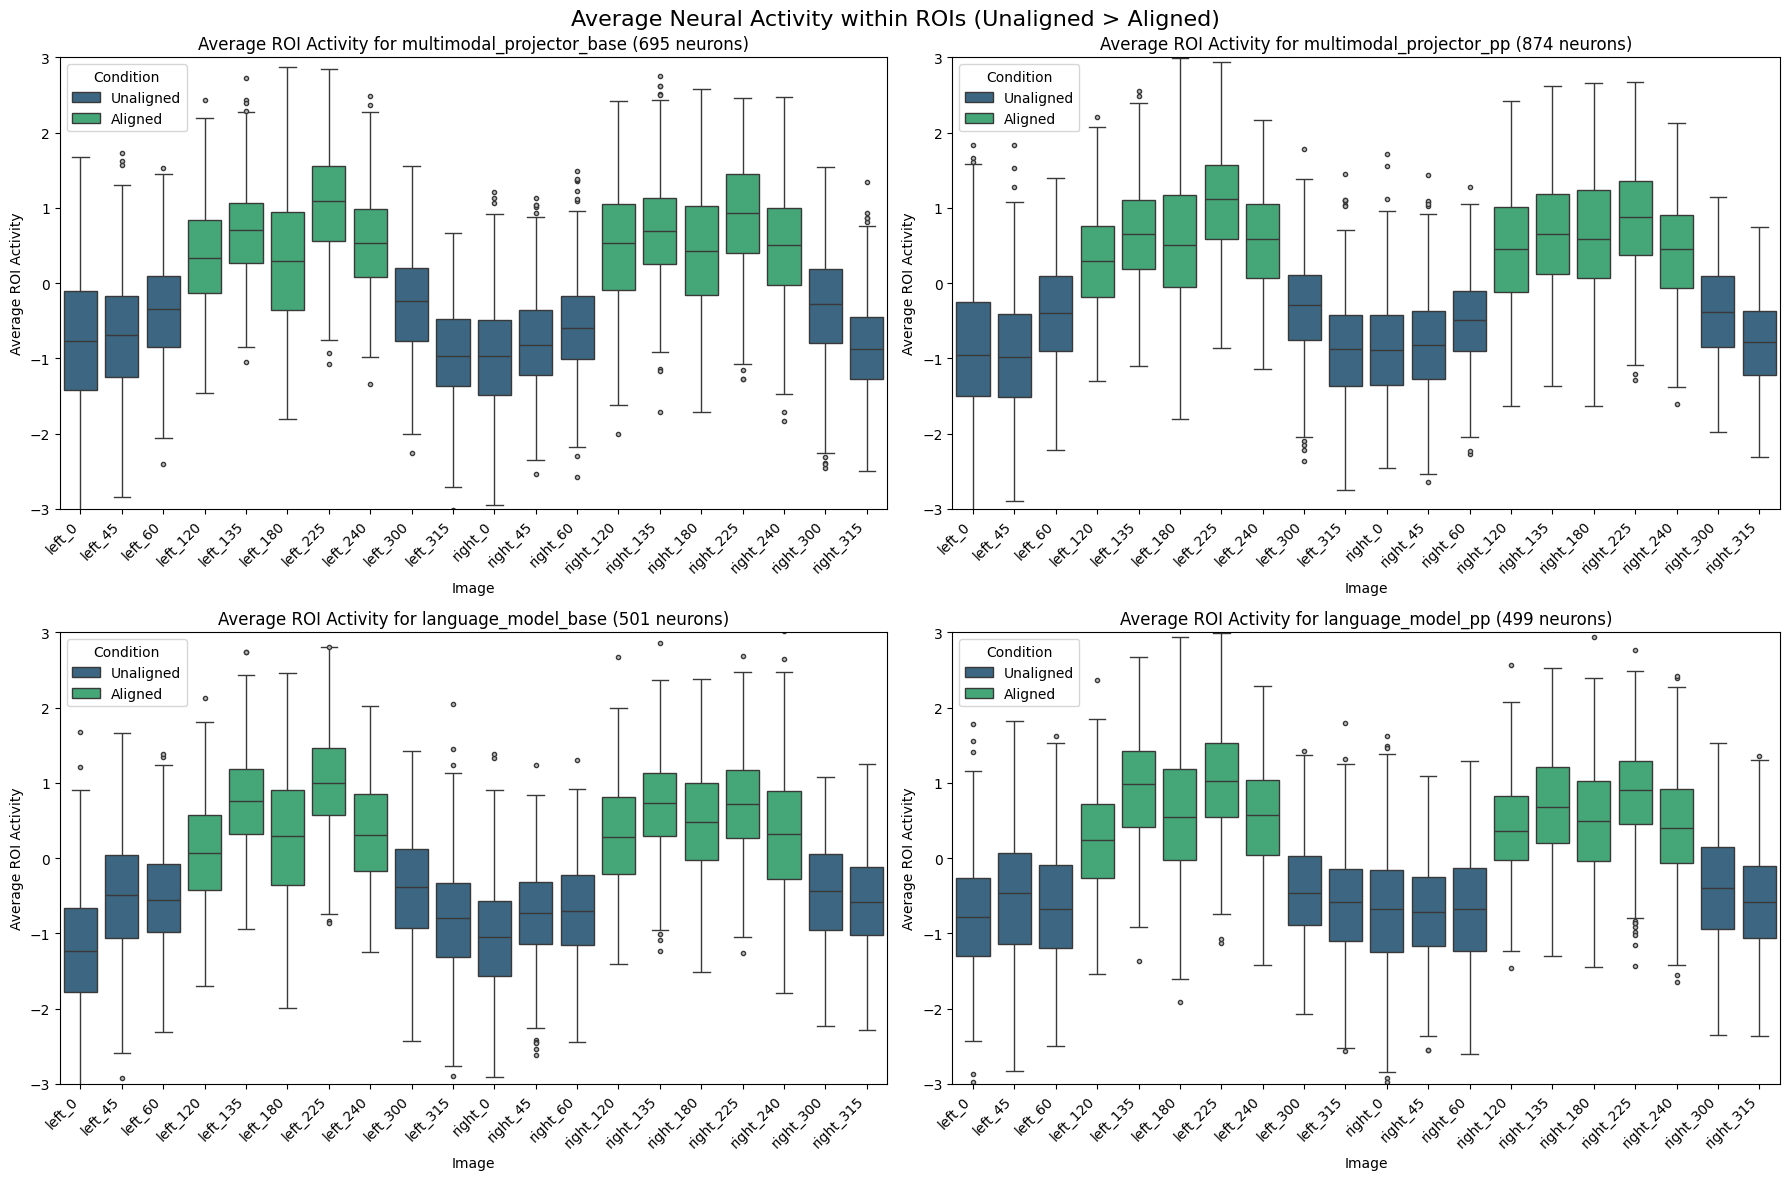

In [31]:
print("\n--- Defining ROIs: Neurons active in Unaligned > Aligned ---")
unalign_neur = {}

for layer_name, activations_matrix in activation_selection.items():
    # Get indices for unaligned and aligned conditions in the filtered data
    unaligned_indices = design_df_filtered[design_df_filtered['alignment'] == 1].index
    aligned_indices = design_df_filtered[design_df_filtered['alignment'] == 0].index

    if len(unaligned_indices) == 0 or len(aligned_indices) == 0:
        print(f"Skipping ROI for {layer_name}: Not enough unaligned or aligned samples after filtering.")
        roi_neurons[layer_name] = []
        continue

    selected_roi_indices = []
    neuron_p_values = []
    for neuron_idx in range(activations_matrix.shape[1]):
        neuron_activity_unaligned = activations_matrix[unaligned_indices, neuron_idx]
        neuron_activity_aligned = activations_matrix[aligned_indices, neuron_idx]

        # Perform independent samples t-test
        # We use equal_var=False for Welch's t-test, which is robust to unequal variances
        # alternative='greater' tests if the mean of unaligned is greater than aligned
        t_stat, p_value = ttest_ind(
            neuron_activity_unaligned,
            neuron_activity_aligned,
            equal_var=False,
            alternative='greater' # Test if unaligned mean > aligned mean
        )

        # Select neuron if p-value is below threshold (and t_stat is positive, which 'greater' ensures)
        if p_value < p_value_threshold:
            selected_roi_indices.append(neuron_idx)
            neuron_p_values.append((p_value, neuron_idx))

    roi_neurons[layer_name] = np.array(selected_roi_indices)
    print(f"ROI for {layer_name}: Found {len(selected_roi_indices)} neurons active in Unaligned > Aligned (p < {p_value_threshold})")

    unalign_neur[layer_name] = len(selected_roi_indices)

    # Sort by p-value (ascending) and get the top N neurons
    neuron_p_values.sort(key=lambda x: x[0]) # Sort by p-value
    top_neurons = [idx for p_val, idx in neuron_p_values[:num_top_neurons]]

    roi_neurons_top100[layer_name] = np.array(top_neurons)
    print(f"ROI for {layer_name}: Selected {len(top_neurons)} top neurons.")

print("\n--- Visualizing Average Neural Activity within ROIs (using filtered data) ---")

left_names = ['left_0', 'left_45', 'left_60', 'left_120', 'left_135', 'left_180', 'left_225', 'left_240', 'left_300', 'left_315']
right_names = ['right_0', 'right_45', 'right_60', 'right_120', 'right_135', 'right_180', 'right_225', 'right_240', 'right_300', 'right_315']
image_names = left_names + right_names
# Create a mapping from image index to image name
image_name_mapping = {i: name for i, name in enumerate(image_names)}

plt.figure(figsize=(18, 12))
for i, (layer_name, activations_matrix) in enumerate(activation_selection.items()):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots

    # Get the ROI for the current layer
    current_roi = roi_neurons[layer_name]

    if len(current_roi) == 0:
        print(f"No neurons found in ROI for {layer_name}. Skipping plot.")
        plt.title(f'{layer_name} - No ROI Neurons')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Image ID')
        plt.ylabel('Average ROI Activity')
        continue

    # Extract activity for ROI neurons across all *filtered* images
    roi_activity = activations_matrix[:, current_roi]

    # Prepare data for seaborn boxplot: (image_id, neuron_activity)
    data_for_boxplot = []
    # The number of images is now activations_matrix.shape[0] (which is 24 - num_perpendicular)
    for img_idx in range(activations_matrix.shape[0]):
        condition = 'Unaligned' if design_df_filtered.iloc[img_idx]['alignment'] == 0 else 'Aligned'
        for neuron_val in roi_activity[img_idx, :]:
            data_for_boxplot.append({'Image ID': image_name_mapping[img_idx], 'Activity': neuron_val, 'Condition': condition})
    plot_df = pd.DataFrame(data_for_boxplot)

    sns.boxplot(x='Image ID', y='Activity', hue='Condition', data=plot_df, palette='viridis', flierprops=dict(markerfacecolor='0.75', markersize=3))
    plt.title(f'Average ROI Activity for {layer_name} ({len(current_roi)} neurons)')
    # The x-axis labels will now correspond to the *new* indices of the filtered images (0 to N-1)
    plt.xlabel('Image')
    plt.ylabel('Average ROI Activity')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Condition')
    if selection == 'sigmoid':
        plt.ylim(0, 1)
    else:
        plt.ylim(-3, 3)

plt.suptitle('Average Neural Activity within ROIs (Unaligned > Aligned)', fontsize=16)
plt.tight_layout()

plt.savefig('data/evals/visuals/unaligned_roi_visualization.png', dpi=300)
plt.show()

num_neurons['unalign_align'] = unalign_neur

# print(f"\n--- Visualizing Average Neural Activity of Top {num_top_neurons} Neurons (Box Plots) ---")

# plt.figure(figsize=(15, 10))
# for i, (layer_name, activations_matrix) in enumerate(activation_selection.items()):
#     plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots

#     # Get the ROI for the current layer (now contains top 100 indices)
#     current_roi = roi_neurons_top100[layer_name]

#     if len(current_roi) == 0:
#         print(f"No top {num_top_neurons} neurons found for {layer_name}. Skipping plot.")
#         plt.title(f'{layer_name} - No Top Neurons (Unaligned > Aligned)')
#         plt.xticks(rotation=45, ha='right')
#         plt.xlabel('Image ID')
#         plt.ylabel('Average ROI Activity')
#         continue

#     # Extract activity for ONLY the top neurons across all filtered images
#     roi_activity = activations_matrix[:, current_roi]

#     # Prepare data for seaborn boxplot: (image_id, neuron_activity)
#     data_for_boxplot = []
#     # Loop over the rows of the *filtered* activation matrix
#     for img_idx in range(activations_matrix.shape[0]):
#         # Get the 'alignment' condition for the current filtered image using .iloc
#         condition = 'Unaligned' if design_df_filtered.iloc[img_idx]['alignment'] == 0 else 'Aligned'
#         for neuron_val in roi_activity[img_idx, :]:
#             data_for_boxplot.append({'Image ID': image_name_mapping[img_idx], 'Activity': neuron_val, 'Condition': condition})
#     plot_df = pd.DataFrame(data_for_boxplot)

#     # Use hue to distinguish unaligned/aligned in the box plot
#     sns.boxplot(x='Image ID', y='Activity', hue='Condition', data=plot_df, palette='viridis', flierprops=dict(markerfacecolor='0.75', markersize=3))
#     plt.title(f'Top {len(current_roi)} Neuron Activity: Unaligned > Aligned for {layer_name}')
#     plt.xlabel('Image')
#     plt.ylabel('Activity (Top ROI Neurons)')
#     plt.xticks(rotation=45, ha='right')
#     if selection == 'sigmoid':
#         plt.ylim(0, 1)
#     elif selection == 'scaled':
#         plt.ylim(-3, 3)
#     plt.legend(title='Condition')

# plt.suptitle(f'Average Activity of Top {num_top_neurons} Neurons (Unaligned > Aligned)', fontsize=16)
# plt.tight_layout()

# plt.savefig('data/evals/visuals/unaligned_top_neurons_roi_visualization.png', dpi=300)
# plt.show()


--- Defining ROIs: Neurons active in Aligned > Unaligned ---
ROI for multimodal_projector_base: Found 609 neurons active in Aligned > Unaligned (p < 0.01)
ROI for multimodal_projector_base: Selected 100 top neurons.


c:\Users\Bridget Leonard\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1074: RuntimeWarning: overflow encountered in divide
  rel_diff = np.max(np.abs(a_zero_mean), axis=axis,


ROI for multimodal_projector_pp: Found 835 neurons active in Aligned > Unaligned (p < 0.01)
ROI for multimodal_projector_pp: Selected 100 top neurons.
ROI for language_model_base: Found 492 neurons active in Aligned > Unaligned (p < 0.01)
ROI for language_model_base: Selected 100 top neurons.
ROI for language_model_pp: Found 518 neurons active in Aligned > Unaligned (p < 0.01)
ROI for language_model_pp: Selected 100 top neurons.

--- Visualizing Average Neural Activity within ROIs (using filtered data) ---


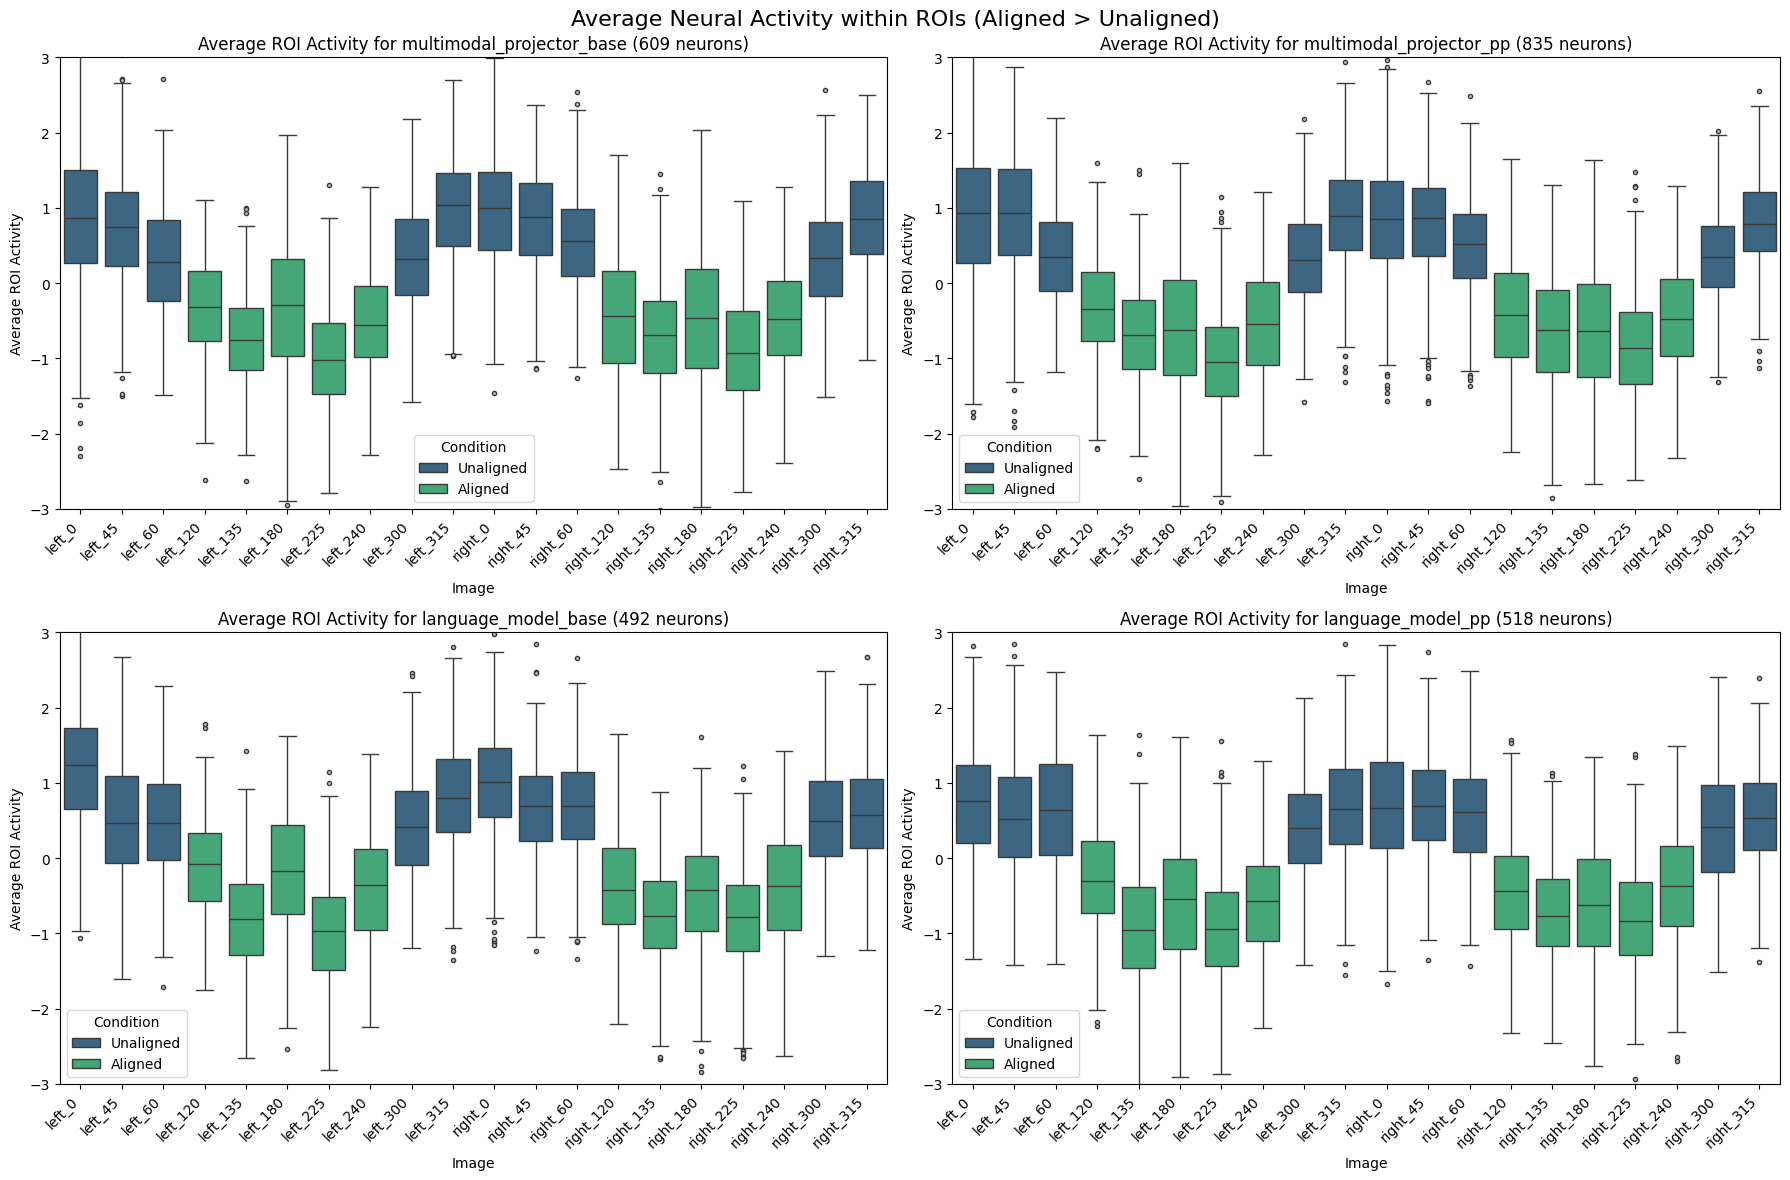

In [42]:
print("\n--- Defining ROIs: Neurons active in Aligned > Unaligned ---")
align_neur = {}

for layer_name, activations_matrix in activation_selection.items():
    # Get indices for unaligned and aligned conditions in the filtered data
    unaligned_indices = design_df_filtered[design_df_filtered['alignment'] == 1].index
    aligned_indices = design_df_filtered[design_df_filtered['alignment'] == 0].index

    if len(unaligned_indices) == 0 or len(aligned_indices) == 0:
        print(f"Skipping ROI for {layer_name}: Not enough unaligned or aligned samples after filtering.")
        roi_neurons[layer_name] = []
        continue

    selected_roi_indices = []
    neuron_p_values = []
    for neuron_idx in range(activations_matrix.shape[1]):
        neuron_activity_unaligned = activations_matrix[unaligned_indices, neuron_idx]
        neuron_activity_aligned = activations_matrix[aligned_indices, neuron_idx]

        # Perform independent samples t-test
        # We use equal_var=False for Welch's t-test, which is robust to unequal variances
        # alternative='greater' tests if the mean of unaligned is greater than aligned
        t_stat, p_value = ttest_ind(
            neuron_activity_aligned,
            neuron_activity_unaligned,
            equal_var=False,
            alternative='greater' # Test if aligned mean > unaligned mean
        )

        # Select neuron if p-value is below threshold (and t_stat is positive, which 'greater' ensures)
        if p_value < p_value_threshold:
            selected_roi_indices.append(neuron_idx)
            neuron_p_values.append((p_value, neuron_idx))

    roi_neurons[layer_name] = np.array(selected_roi_indices)
    print(f"ROI for {layer_name}: Found {len(selected_roi_indices)} neurons active in Aligned > Unaligned (p < {p_value_threshold})")

    align_neur[layer_name] = len(selected_roi_indices)

    # Sort by p-value (ascending) and get the top N neurons
    neuron_p_values.sort(key=lambda x: x[0]) # Sort by p-value
    top_neurons = [idx for p_val, idx in neuron_p_values[:num_top_neurons]]

    roi_neurons_top100[layer_name] = np.array(top_neurons)
    print(f"ROI for {layer_name}: Selected {len(top_neurons)} top neurons.")

print("\n--- Visualizing Average Neural Activity within ROIs (using filtered data) ---")

left_names = ['left_0', 'left_45', 'left_60', 'left_120', 'left_135', 'left_180', 'left_225', 'left_240', 'left_300', 'left_315']
right_names = ['right_0', 'right_45', 'right_60', 'right_120', 'right_135', 'right_180', 'right_225', 'right_240', 'right_300', 'right_315']
image_names = left_names + right_names
# Create a mapping from image index to image name
image_name_mapping = {i: name for i, name in enumerate(image_names)}

plt.figure(figsize=(18, 12))
for i, (layer_name, activations_matrix) in enumerate(activation_selection.items()):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots

    # Get the ROI for the current layer
    current_roi = roi_neurons[layer_name]

    if len(current_roi) == 0:
        print(f"No neurons found in ROI for {layer_name}. Skipping plot.")
        plt.title(f'{layer_name} - No ROI Neurons')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Image ID')
        plt.ylabel('Average ROI Activity')
        continue

    # Extract activity for ROI neurons across all *filtered* images
    roi_activity = activations_matrix[:, current_roi]

    # Prepare data for seaborn boxplot: (image_id, neuron_activity)
    data_for_boxplot = []
    # The number of images is now activations_matrix.shape[0] (which is 24 - num_perpendicular)
    for img_idx in range(activations_matrix.shape[0]):
        condition = 'Unaligned' if design_df_filtered.iloc[img_idx]['alignment'] == 0 else 'Aligned'
        for neuron_val in roi_activity[img_idx, :]:
            data_for_boxplot.append({'Image ID': image_name_mapping[img_idx], 'Activity': neuron_val, 'Condition': condition})
    plot_df = pd.DataFrame(data_for_boxplot)

    sns.boxplot(x='Image ID', y='Activity', hue='Condition', data=plot_df, palette='viridis', flierprops=dict(markerfacecolor='0.75', markersize=3))
    plt.title(f'Average ROI Activity for {layer_name} ({len(current_roi)} neurons)')
    # The x-axis labels will now correspond to the *new* indices of the filtered images (0 to N-1)
    plt.xlabel('Image')
    plt.ylabel('Average ROI Activity')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Condition')
    if selection == 'sigmoid':
        plt.ylim(0, 1)
    else:
        plt.ylim(-3, 3)

plt.suptitle('Average Neural Activity within ROIs (Aligned > Unaligned)', fontsize=16)
plt.tight_layout()

plt.savefig('data/evals/visuals/aligned_roi_visualization.png', dpi=300)
plt.show()

num_neurons['align_unalign'] = align_neur

### Neurons encoding for egocentric cube_direction

In [34]:
# cube_direction already in design_df is egocentric
design_df_filtered['cube_direction'][:3]

0    0
1    0
2    0
Name: cube_direction, dtype: int64

##### left > right


--- Defining ROIs: Neurons active in Left > Right ---


c:\Users\Bridget Leonard\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1074: RuntimeWarning: overflow encountered in divide
  rel_diff = np.max(np.abs(a_zero_mean), axis=axis,


ROI for multimodal_projector_base: Found 0 neurons active in left > right (p < 0.01)
ROI for multimodal_projector_base: Selected 0 top neurons.
ROI for multimodal_projector_pp: Found 0 neurons active in left > right (p < 0.01)
ROI for multimodal_projector_pp: Selected 0 top neurons.
ROI for language_model_base: Found 3 neurons active in left > right (p < 0.01)
ROI for language_model_base: Selected 3 top neurons.
ROI for language_model_pp: Found 40 neurons active in left > right (p < 0.01)
ROI for language_model_pp: Selected 40 top neurons.
No neurons found in ROI for multimodal_projector_base. Skipping plot.
No neurons found in ROI for multimodal_projector_pp. Skipping plot.


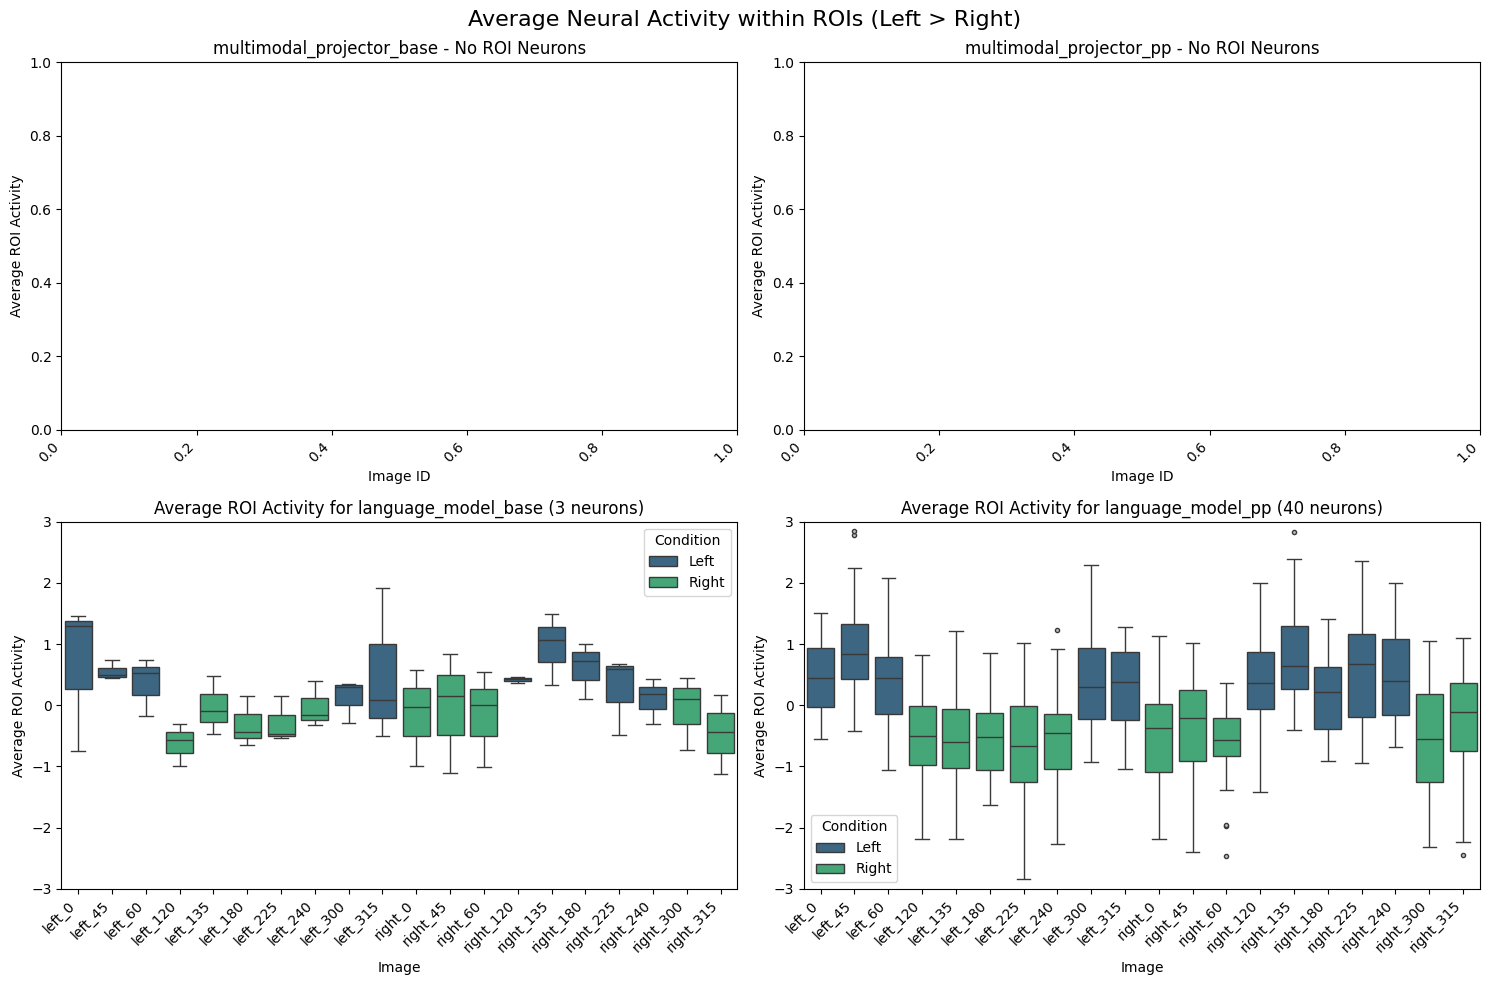

In [35]:
roi_neurons_top100 = {}
num_top_neurons = 100

roi_neurons = {}
p_value_threshold = 0.01 # Significance level for t-test

left_right_neur = {}

print("\n--- Defining ROIs: Neurons active in Left > Right ---")
for layer_name, activations_matrix in activation_selection.items():
    # Get indices for left and right conditions in the filtered data
    left_indices = design_df_filtered[design_df_filtered['cube_direction'] == 0].index
    right_indices = design_df_filtered[design_df_filtered['cube_direction'] == 1].index

    if len(left_indices) == 0 or len(right_indices) == 0:
        print(f"Skipping ROI for {layer_name}: Not enough left or right samples after filtering.")
        roi_neurons[layer_name] = []
        continue

    selected_roi_indices = []
    neuron_p_values = []
    for neuron_idx in range(activations_matrix.shape[1]):
        neuron_activity_left = activations_matrix[left_indices, neuron_idx]
        neuron_activity_right = activations_matrix[right_indices, neuron_idx]

        # Perform independent samples t-test
        # We use equal_var=False for Welch's t-test, which is robust to unequal variances
        # alternative='greater' tests if the mean of left is not equal to right
        t_stat, p_value = ttest_ind(
            neuron_activity_left,
            neuron_activity_right,
            equal_var=False,
            alternative="greater" # Test if left mean > right mean
        )

        # Select neuron if p-value is below threshold (and t_stat is positive, which 'greater' ensures)
        if p_value < p_value_threshold:
            selected_roi_indices.append(neuron_idx)
            neuron_p_values.append((p_value, neuron_idx))

    roi_neurons[layer_name] = np.array(selected_roi_indices)
    print(f"ROI for {layer_name}: Found {len(selected_roi_indices)} neurons active in left > right (p < {p_value_threshold})")
    left_right_neur[layer_name] = len(selected_roi_indices)

    # Sort by p-value (ascending) and get the top N neurons
    neuron_p_values.sort(key=lambda x: x[0]) # Sort by p-value
    top_neurons = [idx for p_val, idx in neuron_p_values[:num_top_neurons]]

    roi_neurons_top100[layer_name] = np.array(top_neurons)
    print(f"ROI for {layer_name}: Selected {len(top_neurons)} top neurons.")

plt.figure(figsize=(15, 10))
for i, (layer_name, activations_matrix) in enumerate(activation_selection.items()):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots

    # Get the ROI for the current layer
    current_roi = roi_neurons[layer_name]

    if len(current_roi) == 0:
        print(f"No neurons found in ROI for {layer_name}. Skipping plot.")
        plt.title(f'{layer_name} - No ROI Neurons')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Image ID')
        plt.ylabel('Average ROI Activity')
        continue

    # Extract activity for ROI neurons across all *filtered* images
    roi_activity = activations_matrix[:, current_roi]

    # Prepare data for seaborn boxplot: (image_id, neuron_activity)
    data_for_boxplot = []
    # The number of images is now activations_matrix.shape[0] (which is 24 - num_perpendicular)
    for img_idx in range(activations_matrix.shape[0]):
        condition = 'Left' if design_df_filtered.iloc[img_idx]['cube_direction'] == 0 else 'Right'
        for neuron_val in roi_activity[img_idx, :]:
            data_for_boxplot.append({'Image ID': image_name_mapping[img_idx], 'Activity': neuron_val, 'Condition': condition})
    plot_df = pd.DataFrame(data_for_boxplot)

    sns.boxplot(x='Image ID', y='Activity', hue='Condition', data=plot_df, palette='viridis', flierprops=dict(markerfacecolor='0.75', markersize=3))
    plt.title(f'Average ROI Activity for {layer_name} ({len(current_roi)} neurons)')
    # The x-axis labels will now correspond to the *new* indices of the filtered images (0 to N-1)
    plt.xlabel('Image')
    plt.ylabel('Average ROI Activity')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Condition')
    if selection == 'sigmoid':
        plt.ylim(0, 1)
    elif selection == 'scaled':
        plt.ylim(-3, 3)

plt.suptitle('Average Neural Activity within ROIs (Left > Right)', fontsize=16)
plt.tight_layout()

plt.savefig('data/evals/visuals/left_right_roi_visualization.png', dpi=300)
plt.show()

num_neurons['left_right'] = left_right_neur

#### right > left


--- Defining ROIs: Neurons active in Left < Right ---


c:\Users\Bridget Leonard\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1074: RuntimeWarning: overflow encountered in divide
  rel_diff = np.max(np.abs(a_zero_mean), axis=axis,


ROI for multimodal_projector_base: Found 1 neurons active in left < right (p < 0.01)
ROI for multimodal_projector_base: Selected 1 top neurons.
ROI for multimodal_projector_pp: Found 0 neurons active in left < right (p < 0.01)
ROI for multimodal_projector_pp: Selected 0 top neurons.
ROI for language_model_base: Found 7 neurons active in left < right (p < 0.01)
ROI for language_model_base: Selected 7 top neurons.
ROI for language_model_pp: Found 52 neurons active in left < right (p < 0.01)
ROI for language_model_pp: Selected 52 top neurons.
No neurons found in ROI for multimodal_projector_pp. Skipping plot.


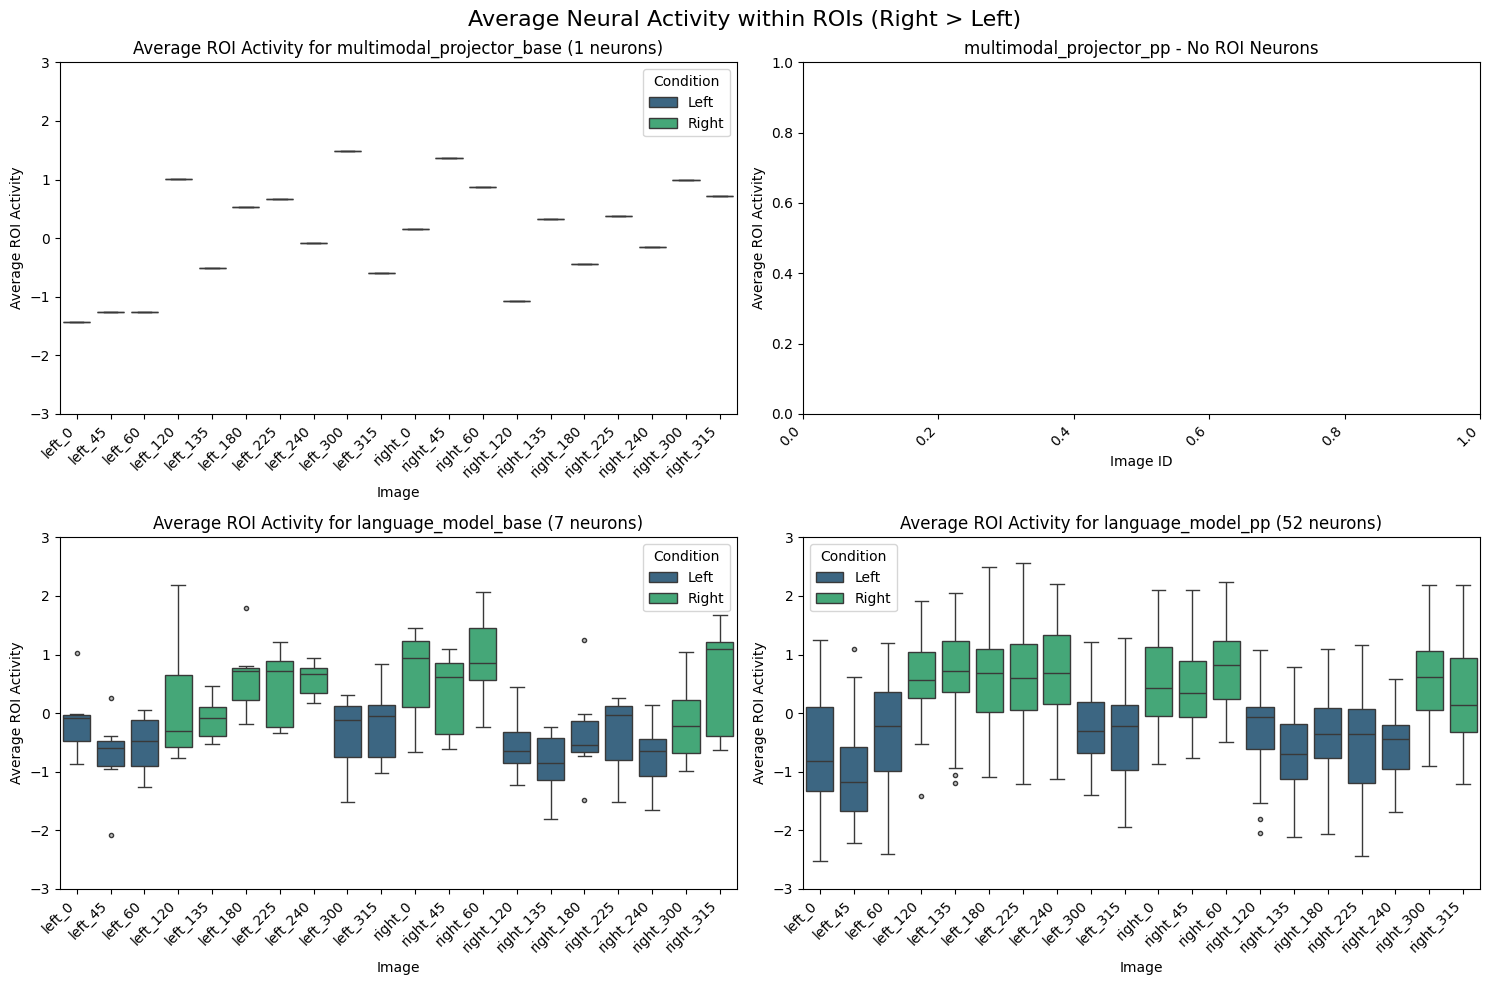

In [36]:
roi_neurons_top100 = {}
num_top_neurons = 100

roi_neurons = {}
p_value_threshold = 0.01 # Significance level for t-test

right_left_neur = {}    

print("\n--- Defining ROIs: Neurons active in Left < Right ---")
for layer_name, activations_matrix in activation_selection.items():
    # Get indices for left and right conditions in the filtered data
    left_indices = design_df_filtered[design_df_filtered['cube_direction'] == 0].index
    right_indices = design_df_filtered[design_df_filtered['cube_direction'] == 1].index

    if len(left_indices) == 0 or len(right_indices) == 0:
        print(f"Skipping ROI for {layer_name}: Not enough left or right samples after filtering.")
        roi_neurons[layer_name] = []
        continue

    selected_roi_indices = []
    neuron_p_values = []
    for neuron_idx in range(activations_matrix.shape[1]):
        neuron_activity_left = activations_matrix[left_indices, neuron_idx]
        neuron_activity_right = activations_matrix[right_indices, neuron_idx]

        # Perform independent samples t-test
        # We use equal_var=False for Welch's t-test, which is robust to unequal variances
        # alternative='greater' tests if the mean of left is not equal to right
        t_stat, p_value = ttest_ind(
            neuron_activity_left,
            neuron_activity_right,
            equal_var=False,
            alternative="less" # Test if left mean < right mean
        )

        # Select neuron if p-value is below threshold (and t_stat is positive, which 'greater' ensures)
        if p_value < p_value_threshold:
            selected_roi_indices.append(neuron_idx)
            neuron_p_values.append((p_value, neuron_idx))

    roi_neurons[layer_name] = np.array(selected_roi_indices)
    print(f"ROI for {layer_name}: Found {len(selected_roi_indices)} neurons active in left < right (p < {p_value_threshold})")
    right_left_neur[layer_name] = len(selected_roi_indices)

    # Sort by p-value (ascending) and get the top N neurons
    neuron_p_values.sort(key=lambda x: x[0]) # Sort by p-value
    top_neurons = [idx for p_val, idx in neuron_p_values[:num_top_neurons]]

    roi_neurons_top100[layer_name] = np.array(top_neurons)
    print(f"ROI for {layer_name}: Selected {len(top_neurons)} top neurons.")

plt.figure(figsize=(15, 10))
for i, (layer_name, activations_matrix) in enumerate(activation_selection.items()):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots

    # Get the ROI for the current layer
    current_roi = roi_neurons[layer_name]

    if len(current_roi) == 0:
        print(f"No neurons found in ROI for {layer_name}. Skipping plot.")
        plt.title(f'{layer_name} - No ROI Neurons')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Image ID')
        plt.ylabel('Average ROI Activity')
        continue

    # Extract activity for ROI neurons across all *filtered* images
    roi_activity = activations_matrix[:, current_roi]

    # Prepare data for seaborn boxplot: (image_id, neuron_activity)
    data_for_boxplot = []
    # The number of images is now activations_matrix.shape[0] (which is 24 - num_perpendicular)
    for img_idx in range(activations_matrix.shape[0]):
        condition = 'Left' if design_df_filtered.iloc[img_idx]['cube_direction'] == 0 else 'Right'
        for neuron_val in roi_activity[img_idx, :]:
            data_for_boxplot.append({'Image ID': image_name_mapping[img_idx], 'Activity': neuron_val, 'Condition': condition})
    plot_df = pd.DataFrame(data_for_boxplot)

    sns.boxplot(x='Image ID', y='Activity', hue='Condition', data=plot_df, palette='viridis', flierprops=dict(markerfacecolor='0.75', markersize=3))
    plt.title(f'Average ROI Activity for {layer_name} ({len(current_roi)} neurons)')
    # The x-axis labels will now correspond to the *new* indices of the filtered images (0 to N-1)
    plt.xlabel('Image')
    plt.ylabel('Average ROI Activity')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Condition')
    if selection == 'sigmoid':
        plt.ylim(0, 1)
    elif selection == 'scaled':
        plt.ylim(-3, 3)

plt.suptitle('Average Neural Activity within ROIs (Right > Left)', fontsize=16)
plt.tight_layout()

plt.savefig('data/evals/visuals/right_left_roi_visualization.png', dpi=300)
plt.show()

num_neurons['right_left'] = right_left_neur

### Neurons encoding for allocentric cube_direction

#### left > right


--- Defining ROIs: Neurons active in Allo Left > Allo Right ---


c:\Users\Bridget Leonard\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1074: RuntimeWarning: overflow encountered in divide
  rel_diff = np.max(np.abs(a_zero_mean), axis=axis,


ROI for multimodal_projector_base: Found 4 neurons active in allo left > right (p < 0.01)
ROI for multimodal_projector_base: Selected 4 top neurons.
ROI for multimodal_projector_pp: Found 6 neurons active in allo left > right (p < 0.01)
ROI for multimodal_projector_pp: Selected 6 top neurons.
ROI for language_model_base: Found 5 neurons active in allo left > right (p < 0.01)
ROI for language_model_base: Selected 5 top neurons.
ROI for language_model_pp: Found 9 neurons active in allo left > right (p < 0.01)
ROI for language_model_pp: Selected 9 top neurons.


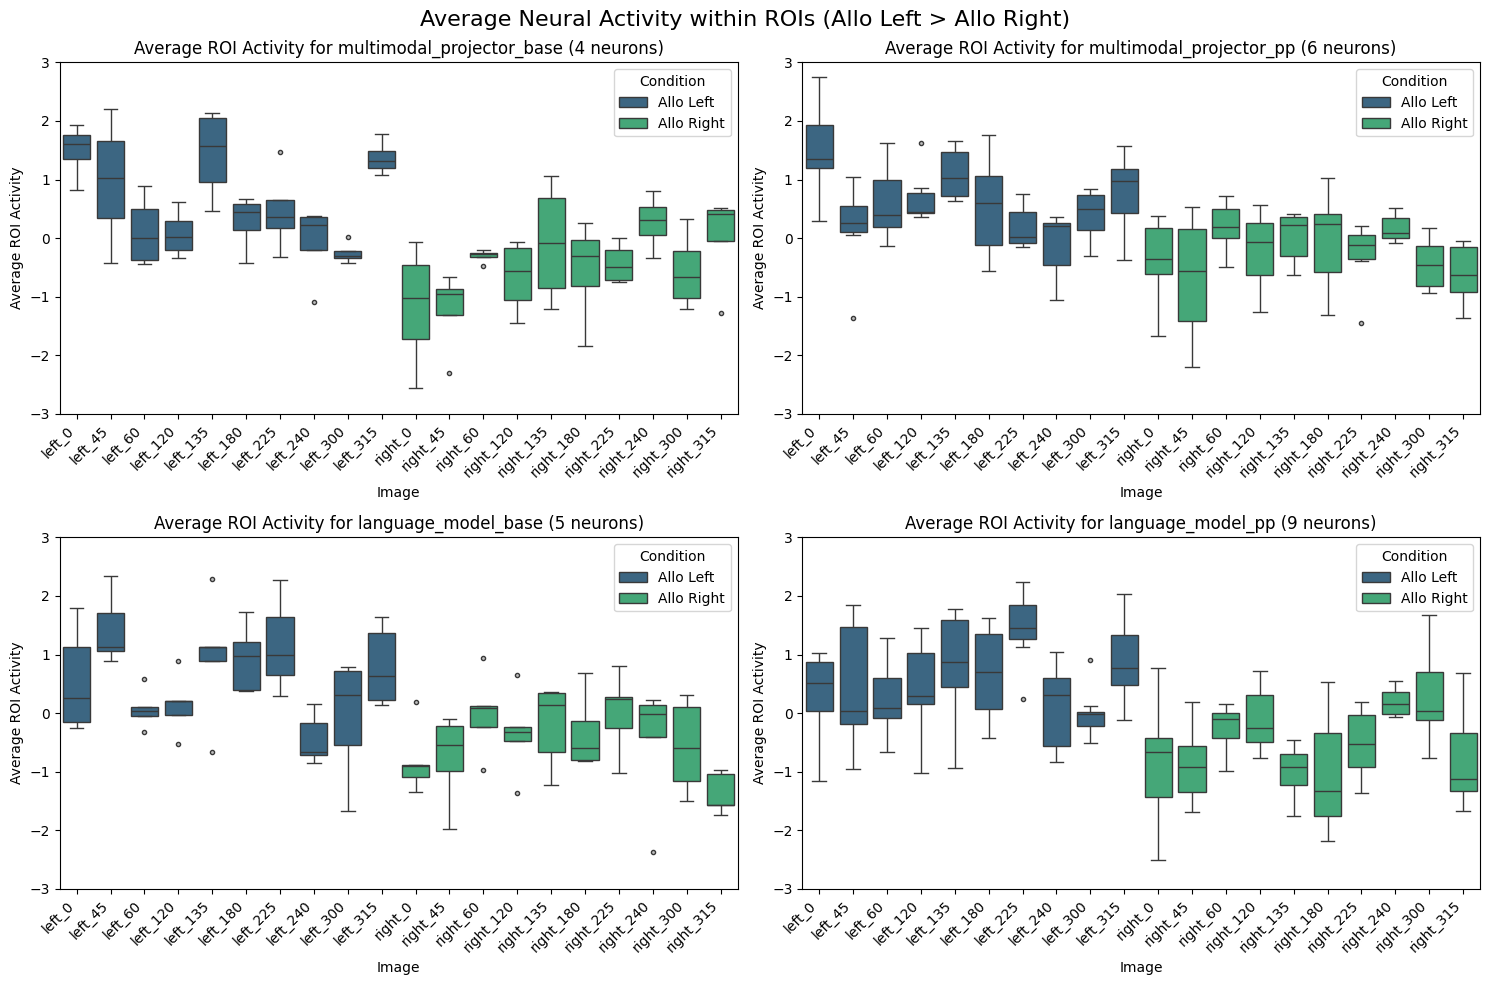

In [38]:
roi_neurons_top100 = {}
num_top_neurons = 100

roi_neurons = {}
p_value_threshold = 0.01 # Significance level for t-test

allo_left_right_neur = {}

print("\n--- Defining ROIs: Neurons active in Allo Left > Allo Right ---")
for layer_name, activations_matrix in activation_selection.items():
    # Get indices for allo left and allo right conditions in the filtered data
    allo_left_indices = design_df_filtered[design_df_filtered['allo_cube_direction'] == 0].index
    allo_right_indices = design_df_filtered[design_df_filtered['allo_cube_direction'] == 1].index

    if len(allo_left_indices) == 0 or len(allo_right_indices) == 0:
        print(f"Skipping ROI for {layer_name}: Not enough allo left or right samples after filtering.")
        roi_neurons[layer_name] = []
        continue

    selected_roi_indices = []
    neuron_p_values = []
    for neuron_idx in range(activations_matrix.shape[1]):
        neuron_activity_allo_left = activations_matrix[allo_left_indices, neuron_idx]
        neuron_activity_allo_right = activations_matrix[allo_right_indices, neuron_idx]

        # Perform independent samples t-test
        # We use equal_var=False for Welch's t-test, which is robust to unequal variances
        # alternative='greater' tests if the mean of allo left is not equal to allo right
        t_stat, p_value = ttest_ind(
            neuron_activity_allo_left,
            neuron_activity_allo_right,
            equal_var=False,
            alternative="greater" # Test if allo left mean > allo right mean
        )

        # Select neuron if p-value is below threshold (and t_stat is positive, which 'greater' ensures)
        if p_value < p_value_threshold:
            selected_roi_indices.append(neuron_idx)
            neuron_p_values.append((p_value, neuron_idx))

    roi_neurons[layer_name] = np.array(selected_roi_indices)
    print(f"ROI for {layer_name}: Found {len(selected_roi_indices)} neurons active in allo left > right (p < {p_value_threshold})")
    allo_left_right_neur[layer_name] = len(selected_roi_indices)

    # Sort by p-value (ascending) and get the top N neurons
    neuron_p_values.sort(key=lambda x: x[0]) # Sort by p-value
    top_neurons = [idx for p_val, idx in neuron_p_values[:num_top_neurons]]

    roi_neurons_top100[layer_name] = np.array(top_neurons)
    print(f"ROI for {layer_name}: Selected {len(top_neurons)} top neurons.")

plt.figure(figsize=(15, 10))
for i, (layer_name, activations_matrix) in enumerate(activation_selection.items()):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots

    # Get the ROI for the current layer
    current_roi = roi_neurons[layer_name]

    if len(current_roi) == 0:
        print(f"No neurons found in ROI for {layer_name}. Skipping plot.")
        plt.title(f'{layer_name} - No ROI Neurons')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Image ID')
        plt.ylabel('Average ROI Activity')
        continue

    # Extract activity for ROI neurons across all *filtered* images
    roi_activity = activations_matrix[:, current_roi]

    # Prepare data for seaborn boxplot: (image_id, neuron_activity)
    data_for_boxplot = []
    # The number of images is now activations_matrix.shape[0] (which is 24 - num_perpendicular)
    for img_idx in range(activations_matrix.shape[0]):
        condition = 'Allo Left' if design_df_filtered.iloc[img_idx]['allo_cube_direction'] == 0 else 'Allo Right'
        for neuron_val in roi_activity[img_idx, :]:
            data_for_boxplot.append({'Image ID': image_name_mapping[img_idx], 'Activity': neuron_val, 'Condition': condition})
    plot_df = pd.DataFrame(data_for_boxplot)

    sns.boxplot(x='Image ID', y='Activity', hue='Condition', data=plot_df, palette='viridis', flierprops=dict(markerfacecolor='0.75', markersize=3))
    plt.title(f'Average ROI Activity for {layer_name} ({len(current_roi)} neurons)')
    # The x-axis labels will now correspond to the *new* indices of the filtered images (0 to N-1)
    plt.xlabel('Image')
    plt.ylabel('Average ROI Activity')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Condition')
    if selection == 'sigmoid':
        plt.ylim(0, 1)
    elif selection == 'scaled':
        plt.ylim(-3, 3)

plt.suptitle('Average Neural Activity within ROIs (Allo Left > Allo Right)', fontsize=16)
plt.tight_layout()
plt.savefig('data/evals/visuals/allo_left_right_roi_visualization.png', dpi=300)
plt.show()

num_neurons['allo_left_right'] = allo_left_right_neur

#### right > left


--- Defining ROIs: Neurons active in Allo Left < Allo Right ---


c:\Users\Bridget Leonard\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1074: RuntimeWarning: overflow encountered in divide
  rel_diff = np.max(np.abs(a_zero_mean), axis=axis,


ROI for multimodal_projector_base: Found 3 neurons active in allo left < right (p < 0.01)
ROI for multimodal_projector_base: Selected 3 top neurons.
ROI for multimodal_projector_pp: Found 1 neurons active in allo left < right (p < 0.01)
ROI for multimodal_projector_pp: Selected 1 top neurons.
ROI for language_model_base: Found 8 neurons active in allo left < right (p < 0.01)
ROI for language_model_base: Selected 8 top neurons.
ROI for language_model_pp: Found 14 neurons active in allo left < right (p < 0.01)
ROI for language_model_pp: Selected 14 top neurons.


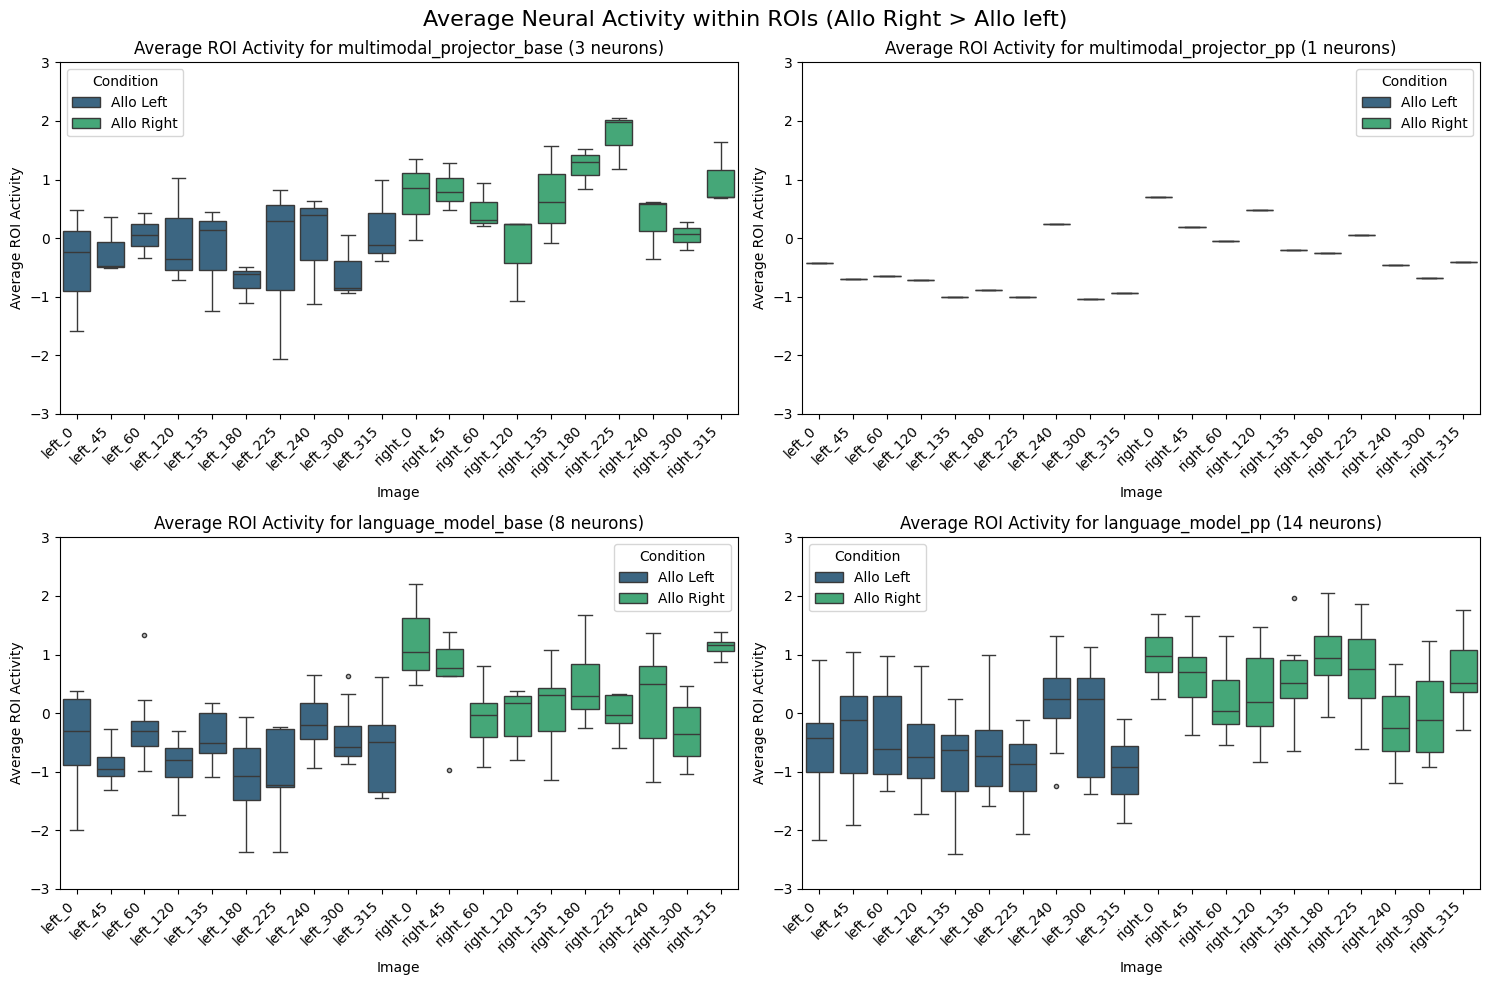

In [39]:
roi_neurons_top100 = {}
num_top_neurons = 100

roi_neurons = {}
p_value_threshold = 0.01 # Significance level for t-test

allo_right_left_neur = {}

print("\n--- Defining ROIs: Neurons active in Allo Left < Allo Right ---")
for layer_name, activations_matrix in scaled_activations_filtered.items():
    # Get indices for allo left and allo right conditions in the filtered data
    allo_left_indices = design_df_filtered[design_df_filtered['allo_cube_direction'] == 0].index
    allo_right_indices = design_df_filtered[design_df_filtered['allo_cube_direction'] == 1].index

    if len(allo_left_indices) == 0 or len(allo_right_indices) == 0:
        print(f"Skipping ROI for {layer_name}: Not enough allo left or right samples after filtering.")
        roi_neurons[layer_name] = []
        continue

    selected_roi_indices = []
    neuron_p_values = []
    for neuron_idx in range(activations_matrix.shape[1]):
        neuron_activity_allo_left = activations_matrix[allo_left_indices, neuron_idx]
        neuron_activity_allo_right = activations_matrix[allo_right_indices, neuron_idx]

        # Perform independent samples t-test
        # We use equal_var=False for Welch's t-test, which is robust to unequal variances
        # alternative='greater' tests if the mean of allo left is not equal to allo right
        t_stat, p_value = ttest_ind(
            neuron_activity_allo_left,
            neuron_activity_allo_right,
            equal_var=False,
            alternative="less" # Test if allo left mean < allo right mean
        )

        # Select neuron if p-value is below threshold (and t_stat is positive, which 'greater' ensures)
        if p_value < p_value_threshold:
            selected_roi_indices.append(neuron_idx)
            neuron_p_values.append((p_value, neuron_idx))

    roi_neurons[layer_name] = np.array(selected_roi_indices)
    print(f"ROI for {layer_name}: Found {len(selected_roi_indices)} neurons active in allo left < right (p < {p_value_threshold})")
    allo_right_left_neur[layer_name] = len(selected_roi_indices)

    # Sort by p-value (ascending) and get the top N neurons
    neuron_p_values.sort(key=lambda x: x[0]) # Sort by p-value
    top_neurons = [idx for p_val, idx in neuron_p_values[:num_top_neurons]]

    roi_neurons_top100[layer_name] = np.array(top_neurons)
    print(f"ROI for {layer_name}: Selected {len(top_neurons)} top neurons.")

plt.figure(figsize=(15, 10))
for i, (layer_name, activations_matrix) in enumerate(scaled_activations_filtered.items()):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots

    # Get the ROI for the current layer
    current_roi = roi_neurons[layer_name]

    if len(current_roi) == 0:
        print(f"No neurons found in ROI for {layer_name}. Skipping plot.")
        plt.title(f'{layer_name} - No ROI Neurons')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Image ID')
        plt.ylabel('Average ROI Activity')
        continue

    # Extract activity for ROI neurons across all *filtered* images
    roi_activity = activations_matrix[:, current_roi]

    # Prepare data for seaborn boxplot: (image_id, neuron_activity)
    data_for_boxplot = []
    # The number of images is now activations_matrix.shape[0] (which is 24 - num_perpendicular)
    for img_idx in range(activations_matrix.shape[0]):
        condition = 'Allo Left' if design_df_filtered.iloc[img_idx]['allo_cube_direction'] == 0 else 'Allo Right'
        for neuron_val in roi_activity[img_idx, :]:
            data_for_boxplot.append({'Image ID': image_name_mapping[img_idx], 'Activity': neuron_val, 'Condition': condition})
    plot_df = pd.DataFrame(data_for_boxplot)

    sns.boxplot(x='Image ID', y='Activity', hue='Condition', data=plot_df, palette='viridis', flierprops=dict(markerfacecolor='0.75', markersize=3))
    plt.title(f'Average ROI Activity for {layer_name} ({len(current_roi)} neurons)')
    # The x-axis labels will now correspond to the *new* indices of the filtered images (0 to N-1)
    plt.xlabel('Image')
    plt.ylabel('Average ROI Activity')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Condition')
    if selection == 'sigmoid':
        plt.ylim(0, 1)
    elif selection == 'scaled':
        plt.ylim(-3, 3)

plt.suptitle('Average Neural Activity within ROIs (Allo Right > Allo left)', fontsize=16)
plt.tight_layout()
plt.savefig('data/evals/visuals/allo_right_left_roi_visualization.png', dpi=300)

plt.show()

num_neurons['allo_right_left'] = allo_right_left_neur

In [40]:
num_neurons

{'alignment': {'multimodal_projector_base': 695,
  'multimodal_projector_pp': 874,
  'language_model_base': 501,
  'language_model_pp': 499},
 'left_right': {'multimodal_projector_base': 0,
  'multimodal_projector_pp': 0,
  'language_model_base': 3,
  'language_model_pp': 40},
 'right_left': {'multimodal_projector_base': 1,
  'multimodal_projector_pp': 0,
  'language_model_base': 7,
  'language_model_pp': 52},
 'allo_left_right': {'multimodal_projector_base': 4,
  'multimodal_projector_pp': 6,
  'language_model_base': 5,
  'language_model_pp': 9},
 'allo_right_left': {'multimodal_projector_base': 3,
  'multimodal_projector_pp': 1,
  'language_model_base': 8,
  'language_model_pp': 14}}

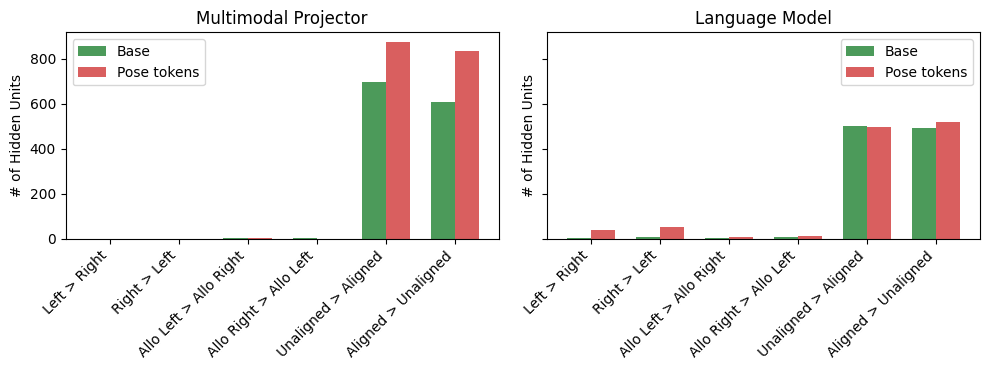

In [90]:
# visualize num_neurons
features_clean = ["Left > Right", "Right > Left", "Allo Left > Allo Right", "Allo Right > Allo Left", "Unaligned > Aligned", "Aligned > Unaligned"]

custom_colors_model = {
    'base': '#4C9A5A',  # muted green
    'pp': '#D95F5F'     # brick red
}

# Convert dict to DataFrame
df = pd.DataFrame(num_neurons).T.reset_index().rename(columns={'index': 'feature'})
df_melted = df.melt(id_vars='feature', var_name='layer_model', value_name='count')

# Extract layer and model type
df_melted['layer'] = df_melted['layer_model'].apply(lambda x: '_'.join(x.split('_')[:2]))
df_melted['model_type'] = df_melted['layer_model'].apply(lambda x: x.split('_')[-1])

# Separate multimodal vs. language
df_multi = df_melted[df_melted['layer'] == 'multimodal_projector']
df_lang = df_melted[df_melted['layer'] == 'language_model']

# Plot grouped bar plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

def plot_grouped(ax, data, title):
    features = data['feature'].unique()
    x = range(len(features))
    width = 0.35
    
    base_vals = data[data['model_type'] == 'base'].set_index('feature')['count']
    pp_vals   = data[data['model_type'] == 'pp'].set_index('feature')['count']
    
    ax.bar([i - width/2 for i in x], base_vals[features], width, label='Base', color=custom_colors_model['base'])
    ax.bar([i + width/2 for i in x], pp_vals[features], width, label='Pose tokens', color=custom_colors_model['pp'])
    
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(features_clean, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel("# of Hidden Units")
    ax.legend()

plot_grouped(axes[0], df_multi, "Multimodal Projector")
plot_grouped(axes[1], df_lang, "Language Model")

#plt.suptitle("Base vs Pose Model Neuron Counts by Feature", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('data/evals/visuals/neuron_counts_by_feature.png', dpi=300)

plt.show()